# Executed DiT results snapshot

Great Lakes outputs from the DiT depth sweep shown in the July 2026 discussion. This snapshot covers the original 200k-update DiT-L8, DiT-L12/base, and DiT-L16 runs. The later controlled DiT-L16 225k--300k continuation study is intentionally not included because those analysis tables were not available in this executed download.

To keep the GitHub preview readable, the duplicate saved-figure gallery and two redundant small-data image grids were removed from the saved outputs. The analysis cells remain runnable.


## tl;dr

- The DiT jobs use the same Fig.2-style protocol as the UNet sweep: fixed update budget, no augmentation, generated samples evaluated by PCA/SSCD nearest-neighbor similarity.
- Treat `DiT-L8`, `DiT-L12/base`, and `DiT-L16` as separate architectures. Do not collapse them into one “DiT” curve.
- The first thing to check is whether the DiT transition shifts with depth, then whether DiT behaves like an equal-parameter UNet or follows a different architecture-specific curve.

## Setup


In [1]:
from __future__ import annotations

import json
import math
import os
import re
import sys
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def parse_csv_env(name: str, default: str) -> list[str]:
    return [x.strip() for x in os.environ.get(name, default).split(',') if x.strip()]


def find_project_dir() -> Path:
    env = os.environ.get('DIFFUSION_PROJECT_DIR')
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / 'scripts').exists() and (candidate / 'notebooks').exists():
            return candidate
    return here


PROJECT_DIR = find_project_dir()
SWEEP_NAME = 'nf_generalize_fig2_dit'
RESULTS_DIR = PROJECT_DIR / 'results' / SWEEP_NAME
TABLE_DIR = RESULTS_DIR / 'tables'
QUICKCHECK_DIR = RESULTS_DIR / 'quickcheck'
SAMPLE_DIR = RESULTS_DIR / 'samples'
MANIFEST_PATH = PROJECT_DIR / 'local' / SWEEP_NAME / 'manifest.json'
SAMPLE_LABEL = os.environ.get('SAMPLE_LABEL', 'dpm50')
SEED = int(os.environ.get('SEED', '123'))

DIT_ARCH_ORDER = ['dit_l8', 'dit_base', 'dit_l16']
DIT_ARCH_LABELS = {
    'dit_l8': 'DiT-L8',
    'dit_base': 'DiT-L12 / base',
    'dit': 'DiT-L12 / base',
    'dit_l16': 'DiT-L16',
}
DIT_ARCH_COLORS = {
    'dit_l8': '#009E73',
    'dit_base': '#000000',
    'dit': '#000000',
    'dit_l16': '#CC79A7',
}
DIT_ARCH_MARKERS = {'dit_l8': 'P', 'dit_base': 'D', 'dit': 'D', 'dit_l16': 'X'}
UNET_ARCH_ORDER = ['u64', 'u128', 'u256']
UNET_ARCH_LABELS = {'u64': 'UNet-64', 'u128': 'UNet-128', 'u256': 'UNet-256'}
UNET_ARCH_COLORS = {'u64': '#009E73', 'u128': '#D55E00', 'u256': '#0072B2'}
UNET_ARCH_MARKERS = {'u64': '^', 'u128': 'o', 'u256': 's'}

DETAIL_ARCH = os.environ.get('DIT_DETAIL_ARCH', 'dit_base')
IMAGE_ARCH = os.environ.get('DIT_IMAGE_ARCH', DETAIL_ARCH)
LOSS_ARCHES = parse_csv_env('DIT_LOSS_ARCHES', 'dit_l8,dit_base,dit_l16')
LOSS_TAGS = parse_csv_env('DIT_LOSS_TAGS', 'd2p06,d2p10,d2p15')
DETAIL_TAGS = parse_csv_env('DIT_DETAIL_TAGS', 'd2p06,d2p08,d2p10,d2p12,d2p15')
IMAGE_TAGS = parse_csv_env('DIT_IMAGE_TAGS', 'd2p06,d2p08,d2p10,d2p12,d2p15')

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

print('PROJECT_DIR =', PROJECT_DIR)
print('RESULTS_DIR =', RESULTS_DIR)
print('SAMPLE_LABEL =', SAMPLE_LABEL)
print('SEED =', SEED)
print('DETAIL_ARCH =', DETAIL_ARCH, 'IMAGE_ARCH =', IMAGE_ARCH)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

try:
    from simdiff_eval.io import as_nchw, load_real_from_config
    from simdiff_eval.metrics import batch_power_spectra, field_histogram
    SIMDIFF_EVAL_AVAILABLE = True
except Exception as exc:
    SIMDIFF_EVAL_AVAILABLE = False
    SIMDIFF_EVAL_ERROR = repr(exc)
    print('simdiff_eval unavailable; image/P(k) diagnostics will be skipped:', SIMDIFF_EVAL_ERROR)

PK_NBINS = int(os.environ.get('DIT_PK_NBINS', '30'))
MAX_GENERATED = int(os.environ.get('DIT_MAX_GENERATED', '512'))
MAX_REAL_RAW_CUBES = int(os.environ.get('DIT_MAX_REAL_RAW_CUBES', '16'))

PROJECT_DIR = /home/jiamingp/diffusion_models_repo
RESULTS_DIR = /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit
SAMPLE_LABEL = dpm50
SEED = 123
DETAIL_ARCH = dit_base IMAGE_ARCH = dit_base


## Context & Methods

These runs use Hugging Face diffusers `DiTTransformer2DModel` with a single null class label (`class_labels=0`) because the DiT adaLN path requires labels even for unconditional training. The label is constant, so this is still an unconditional Fig.2-style sweep.

The depth sweep is:

- `DiT-L8`: 8 transformer blocks, width 768.
- `DiT-L12/base`: the original DiT-base run, 12 transformer blocks, width 768.
- `DiT-L16`: 16 transformer blocks, width 768.

Each model is trained at the same 2D training-set sizes as the UNet Fig.2 sweep, then sampled with DPM-Solver 50 steps. The diagnostics below ask whether deeper DiTs need more data before generated fields stop looking like nearest training slices.

## Data Audit


In [2]:
def read_json(path: Path) -> Any | None:
    if not path.exists():
        return None
    with path.open() as f:
        return json.load(f)


def rel(path: Path | str | None) -> str:
    if path is None:
        return ''
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_DIR))
    except ValueError:
        return str(path)


def dataset_tag_from_name(name: str) -> str | None:
    m = re.search(r'd2p(\d+)', str(name))
    if not m:
        return None
    return 'd2p' + m.group(1)


def dataset_size_from_tag(tag: str | None) -> int | None:
    if not tag:
        return None
    m = re.match(r'd2p(\d+)', tag)
    if not m:
        return None
    return 2 ** int(m.group(1))


def arch_from_run_name(name: str) -> str:
    text = str(name)
    for arch in ['dit_l16', 'dit_l8', 'dit_base', 'u256', 'u128', 'u64']:
        if arch in text:
            return arch
    if re.search(r'\bdit\b', text):
        return 'dit_base'
    return 'unknown'


def arch_label(raw: Any) -> str:
    text = str(raw)
    if text in DIT_ARCH_LABELS:
        return DIT_ARCH_LABELS[text]
    if text in UNET_ARCH_LABELS:
        return UNET_ARCH_LABELS[text]
    return text


def ensure_arch_columns(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    if 'arch' not in out.columns:
        name_col = 'run_name' if 'run_name' in out.columns else ('name' if 'name' in out.columns else None)
        out['arch'] = out[name_col].map(arch_from_run_name) if name_col else 'unknown'
    else:
        out['arch'] = out['arch'].astype(str).replace({'dit': 'dit_base'})
    if 'arch_label' not in out.columns:
        out['arch_label'] = out['arch'].map(arch_label)
    return out


def dataset_size_label(n: int | float) -> str:
    n = int(n)
    log2n = np.log2(n)
    if np.isfinite(log2n) and abs(log2n - round(log2n)) < 1e-9:
        return rf'$2^{{{int(round(log2n))}}}$'
    return f'{n:,}'


def sample_path_for(row: pd.Series) -> Path:
    raw = str(row.get('sample_path', '') or '')
    if raw:
        raw = raw.format(seed=SEED, sample_label=SAMPLE_LABEL)
        path = Path(raw)
        return path if path.is_absolute() else PROJECT_DIR / path
    run_name = row.get('run_name') or row.get('name')
    arch = row.get('arch') or arch_from_run_name(str(run_name))
    tag = row.get('dataset_tag') or dataset_tag_from_name(str(run_name))
    if tag is None:
        return SAMPLE_DIR / f'unknown_seed{SEED}_{SAMPLE_LABEL}.npz'
    return SAMPLE_DIR / f'nf_fig2_{arch}_{tag}_noaug_200k_seed{SEED}_{SAMPLE_LABEL}.npz'


manifest_obj = read_json(MANIFEST_PATH)
if manifest_obj is None:
    display(Markdown(f'**Missing manifest:** `{rel(MANIFEST_PATH)}`'))
    manifest_df = pd.DataFrame()
else:
    if isinstance(manifest_obj, dict):
        rows = manifest_obj.get('runs', [])
    elif isinstance(manifest_obj, list):
        rows = manifest_obj
    else:
        rows = []
    manifest_df = pd.DataFrame(rows)
    if 'run_name' not in manifest_df.columns and 'name' in manifest_df.columns:
        manifest_df['run_name'] = manifest_df['name']
    manifest_df = ensure_arch_columns(manifest_df)
    if 'dataset_tag' not in manifest_df.columns:
        manifest_df['dataset_tag'] = manifest_df['run_name'].map(dataset_tag_from_name)
    if 'dataset_size' not in manifest_df.columns:
        manifest_df['dataset_size'] = manifest_df['dataset_tag'].map(dataset_size_from_tag)
    manifest_df['sample_path_resolved'] = manifest_df.apply(sample_path_for, axis=1)
    manifest_df['sample_exists'] = manifest_df['sample_path_resolved'].map(Path.exists)
    manifest_df['sample_size_mb'] = manifest_df['sample_path_resolved'].map(lambda p: p.stat().st_size / 1024**2 if p.exists() else np.nan)

    show_cols = [c for c in [
        'arch', 'arch_label', 'run_name', 'dataset_tag', 'dataset_size', 'sample_exists', 'sample_size_mb',
        'config_path', 'output_dir', 'sample_path_resolved'
    ] if c in manifest_df.columns]
    display(manifest_df.sort_values(['arch', 'dataset_size'])[show_cols])
    print(f"sample files present: {manifest_df['sample_exists'].sum()} / {len(manifest_df)}")

expected_tables = [
    TABLE_DIR / 'nf_generalize_fig2_dit_pca_full_nn_metrics.csv',
    TABLE_DIR / 'nf_generalize_fig2_dit_pca_full_nn_mode_norms.csv',
    TABLE_DIR / 'nf_generalize_fig2_dit_pca_full_nn_similarity_histograms.csv',
    TABLE_DIR / 'nf_generalize_fig2_dit_sscd_full_nn_metrics.csv',
]
expected_figures = [
    QUICKCHECK_DIR / 'nf_generalize_fig2_dit_pca_full_nn_paper_style_gl_curves.png',
    QUICKCHECK_DIR / 'nf_generalize_fig2_dit_sscd_full_nn_paper_style_gl_curves.png',
    QUICKCHECK_DIR / 'nf_generalize_fig2_dit_pca_full_nn_similarity_curves.png',
    QUICKCHECK_DIR / 'nf_generalize_fig2_dit_sscd_full_nn_similarity_curves.png',
    QUICKCHECK_DIR / 'nf_generalize_fig2_dit_pca_full_nn_copy_fraction_curves.png',
    QUICKCHECK_DIR / 'nf_generalize_fig2_dit_sscd_full_nn_copy_fraction_curves.png',
]

audit = pd.DataFrame({
    'path': [rel(p) for p in expected_tables + expected_figures],
    'kind': ['table'] * len(expected_tables) + ['figure'] * len(expected_figures),
    'exists': [p.exists() for p in expected_tables + expected_figures],
    'size_mb': [p.stat().st_size / 1024**2 if p.exists() else np.nan for p in expected_tables + expected_figures],
})
display(audit)

,arch,arch_label,run_name,dataset_tag,dataset_size,sample_exists,sample_size_mb,sample_path_resolved
10,dit_base,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
11,dit_base,DiT-base,nf_fig2_dit_base_d2p07_noaug_200k,d2p07,128,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
12,dit_base,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
13,dit_base,DiT-base,nf_fig2_dit_base_d2p09_noaug_200k,d2p09,512,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
14,dit_base,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
15,dit_base,DiT-base,nf_fig2_dit_base_d2p11_noaug_200k,d2p11,2048,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
16,dit_base,DiT-base,nf_fig2_dit_base_d2p12_noaug_200k,d2p12,4096,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
17,dit_base,DiT-base,nf_fig2_dit_base_d2p13_noaug_200k,d2p13,8192,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
18,dit_base,DiT-base,nf_fig2_dit_base_d2p14_noaug_200k,d2p14,16384,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...
19,dit_base,DiT-base,nf_fig2_dit_base_d2p15_noaug_200k,d2p15,32768,True,32.000256,/home/jiamingp/diffusion_models_repo/results/n...


sample files present: 30 / 30


,path,kind,exists,size_mb
0,results/nf_generalize_fig2_dit/tables/nf_gener...,table,True,0.033067
1,results/nf_generalize_fig2_dit/tables/nf_gener...,table,True,0.882744
2,results/nf_generalize_fig2_dit/tables/nf_gener...,table,True,1.776779
3,results/nf_generalize_fig2_dit/tables/nf_gener...,table,True,0.032537
4,results/nf_generalize_fig2_dit/quickcheck/nf_g...,figure,True,0.556023
5,results/nf_generalize_fig2_dit/quickcheck/nf_g...,figure,True,0.338186
6,results/nf_generalize_fig2_dit/quickcheck/nf_g...,figure,True,0.362037
7,results/nf_generalize_fig2_dit/quickcheck/nf_g...,figure,True,0.321531
8,results/nf_generalize_fig2_dit/quickcheck/nf_g...,figure,True,0.249882
9,results/nf_generalize_fig2_dit/quickcheck/nf_g...,figure,True,0.102862


## Load Metrics


In [3]:
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if not path.exists():
        display(Markdown(f'**Missing table:** `{rel(path)}`'))
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f'loaded {rel(path)}: {len(df)} rows, {len(df.columns)} columns')
    return df


def add_generalization_columns(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    df = ensure_arch_columns(df)
    for q in ['q50', 'q68', 'q90', 'q95', 'q99']:
        copy_col = f'gen_copy_fraction_{q}'
        gl_col = f'gen_gl_{q}'
        if gl_col not in df.columns and copy_col in df.columns:
            df[gl_col] = 1.0 - df[copy_col]
    # Some older tables used shorter names.
    for q in ['q90', 'q95', 'q99']:
        if f'gen_gl_{q}' not in df.columns and f'copy_fraction_{q}' in df.columns:
            df[f'gen_gl_{q}'] = 1.0 - df[f'copy_fraction_{q}']
    if 'dataset_tag' not in df.columns:
        name_col = 'run_name' if 'run_name' in df.columns else df.columns[0]
        df['dataset_tag'] = df[name_col].map(dataset_tag_from_name)
    if 'dataset_size' not in df.columns:
        df['dataset_size'] = df['dataset_tag'].map(dataset_size_from_tag)
    return df


pca_metrics = add_generalization_columns(read_csv_if_exists(TABLE_DIR / 'nf_generalize_fig2_dit_pca_full_nn_metrics.csv'))
sscd_metrics = add_generalization_columns(read_csv_if_exists(TABLE_DIR / 'nf_generalize_fig2_dit_sscd_full_nn_metrics.csv'))

for feature_name, df in [('PCA', pca_metrics), ('SSCD', sscd_metrics)]:
    display(Markdown(f'### {feature_name} metrics'))
    if df.empty:
        continue
    print('architectures:', sorted(df['arch'].dropna().unique()) if 'arch' in df.columns else 'missing')
    print('generalization columns:', [c for c in df.columns if c.startswith('gen_gl')])
    preferred = [
        'arch_label', 'run_name', 'dataset_tag', 'dataset_size', 'n_generated', 'n_train',
        'gen_gl_q90', 'gen_gl_q95', 'gen_gl_q99',
        'gen_copy_fraction_q95', 'threshold_q95', 'gen_nn_median', 'gen_nn_q95'
    ]
    cols = [c for c in preferred if c in df.columns]
    display(df.sort_values(['arch', 'dataset_size'])[cols] if cols else df.head())

loaded results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_pca_full_nn_metrics.csv: 30 rows, 89 columns
loaded results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_sscd_full_nn_metrics.csv: 30 rows, 89 columns


### PCA metrics

architectures: ['dit_base', 'dit_l16', 'dit_l8']
generalization columns: ['gen_gl_q90', 'gen_gl_q95', 'gen_gl_q99', 'gen_gl_fixed_0p5', 'gen_gl_fixed_0p6', 'gen_gl_fixed_0p7', 'gen_gl_fixed_0p8', 'gen_gl_fixed_0p9', 'gen_gl_fixed_0p95']


,arch_label,run_name,dataset_tag,dataset_size,n_generated,gen_gl_q90,gen_gl_q95,gen_gl_q99,gen_copy_fraction_q95,threshold_q95,gen_nn_median,gen_nn_q95
0,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,512,0.000000,0.000000,0.000000,1.000000,0.725829,0.999944,0.999959
1,DiT-base,nf_fig2_dit_base_d2p07_noaug_200k,d2p07,128,512,0.005859,0.005859,0.005859,0.994141,0.955543,0.999836,0.999882
2,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,512,0.113281,0.113281,0.123047,0.886719,0.970366,0.999266,0.999618
3,DiT-base,nf_fig2_dit_base_d2p09_noaug_200k,d2p09,512,512,0.037109,0.048828,0.062500,0.951172,0.966680,0.997502,0.998632
4,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,512,0.220703,0.314453,0.675781,0.685547,0.976933,0.985914,0.994738
5,DiT-base,nf_fig2_dit_base_d2p11_noaug_200k,d2p11,2048,512,1.000000,1.000000,1.000000,0.000000,0.969577,0.692017,0.905927
6,DiT-base,nf_fig2_dit_base_d2p12_noaug_200k,d2p12,4096,512,1.000000,1.000000,1.000000,0.000000,0.960727,0.321110,0.632473
7,DiT-base,nf_fig2_dit_base_d2p13_noaug_200k,d2p13,8192,512,1.000000,1.000000,1.000000,0.000000,0.941277,0.332559,0.566641
8,DiT-base,nf_fig2_dit_base_d2p14_noaug_200k,d2p14,16384,512,1.000000,1.000000,1.000000,0.000000,0.888976,0.410474,0.642519
9,DiT-base,nf_fig2_dit_base_d2p15_noaug_200k,d2p15,32768,512,1.000000,1.000000,1.000000,0.000000,0.789870,0.319531,0.556771


### SSCD metrics

architectures: ['dit_base', 'dit_l16', 'dit_l8']
generalization columns: ['gen_gl_q90', 'gen_gl_q95', 'gen_gl_q99', 'gen_gl_fixed_0p5', 'gen_gl_fixed_0p6', 'gen_gl_fixed_0p7', 'gen_gl_fixed_0p8', 'gen_gl_fixed_0p9', 'gen_gl_fixed_0p95']


,arch_label,run_name,dataset_tag,dataset_size,n_generated,gen_gl_q90,gen_gl_q95,gen_gl_q99,gen_copy_fraction_q95,threshold_q95,gen_nn_median,gen_nn_q95
0,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,512,0.000000,0.000000,0.000000,1.000000,0.917692,0.999078,0.999566
1,DiT-base,nf_fig2_dit_base_d2p07_noaug_200k,d2p07,128,512,0.005859,0.005859,0.007812,0.994141,0.955569,0.997727,0.998985
2,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,512,0.169922,0.283203,0.453125,0.716797,0.981710,0.989269,0.996713
3,DiT-base,nf_fig2_dit_base_d2p09_noaug_200k,d2p09,512,512,0.445312,0.583984,0.908203,0.416016,0.976412,0.971575,0.987814
4,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,512,0.910156,0.998047,1.000000,0.001953,0.983245,0.931928,0.975379
5,DiT-base,nf_fig2_dit_base_d2p11_noaug_200k,d2p11,2048,512,1.000000,1.000000,1.000000,0.000000,0.974986,0.792264,0.886857
6,DiT-base,nf_fig2_dit_base_d2p12_noaug_200k,d2p12,4096,512,1.000000,1.000000,1.000000,0.000000,0.965154,0.848347,0.876603
7,DiT-base,nf_fig2_dit_base_d2p13_noaug_200k,d2p13,8192,512,1.000000,1.000000,1.000000,0.000000,0.950544,0.833398,0.870353
8,DiT-base,nf_fig2_dit_base_d2p14_noaug_200k,d2p14,16384,512,0.998047,1.000000,1.000000,0.000000,0.926127,0.839543,0.875181
9,DiT-base,nf_fig2_dit_base_d2p15_noaug_200k,d2p15,32768,512,0.992188,1.000000,1.000000,0.000000,0.907199,0.847778,0.883426


## Training Loss Curves

This reads the latest checkpoint metrics for each DiT run and plots loss against optimizer update. Loss is not a fidelity metric, but it is useful for catching unfinished or unstable runs before interpreting samples.


,arch,arch_label,run_name,dataset_tag,dataset_size,steps_per_epoch,metrics_path,n_epoch_loss,final_epoch_loss,best_epoch_loss,n_batch_loss,final_batch_loss
0,dit_base,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,8,/scratch/huterer_root/huterer0/jiamingp/saved_...,25000,0.000184,0.000049,800000,0.000046
1,dit_base,DiT-base,nf_fig2_dit_base_d2p07_noaug_200k,d2p07,128,16,/scratch/huterer_root/huterer0/jiamingp/saved_...,12500,0.000217,0.000142,800000,0.000191
2,dit_base,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,32,/scratch/huterer_root/huterer0/jiamingp/saved_...,6250,0.000442,0.000344,800000,0.000168
3,dit_base,DiT-base,nf_fig2_dit_base_d2p09_noaug_200k,d2p09,512,64,/scratch/huterer_root/huterer0/jiamingp/saved_...,3125,0.000810,0.000756,800000,0.000816
4,dit_base,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,128,/scratch/huterer_root/huterer0/jiamingp/saved_...,1563,0.001528,0.001528,800256,0.001304
5,dit_base,DiT-base,nf_fig2_dit_base_d2p11_noaug_200k,d2p11,2048,256,/scratch/huterer_root/huterer0/jiamingp/saved_...,782,0.004504,0.004169,800768,0.009078
6,dit_base,DiT-base,nf_fig2_dit_base_d2p12_noaug_200k,d2p12,4096,512,/scratch/huterer_root/huterer0/jiamingp/saved_...,391,0.010623,0.010567,800768,0.009713
7,dit_base,DiT-base,nf_fig2_dit_base_d2p13_noaug_200k,d2p13,8192,1024,/scratch/huterer_root/huterer0/jiamingp/saved_...,196,0.012635,0.012369,802816,0.005024
8,dit_base,DiT-base,nf_fig2_dit_base_d2p14_noaug_200k,d2p14,16384,2048,/scratch/huterer_root/huterer0/jiamingp/saved_...,98,0.012808,0.012617,802816,0.013689
9,dit_base,DiT-base,nf_fig2_dit_base_d2p15_noaug_200k,d2p15,32768,4096,/scratch/huterer_root/huterer0/jiamingp/saved_...,49,0.012834,0.012654,802816,0.019759


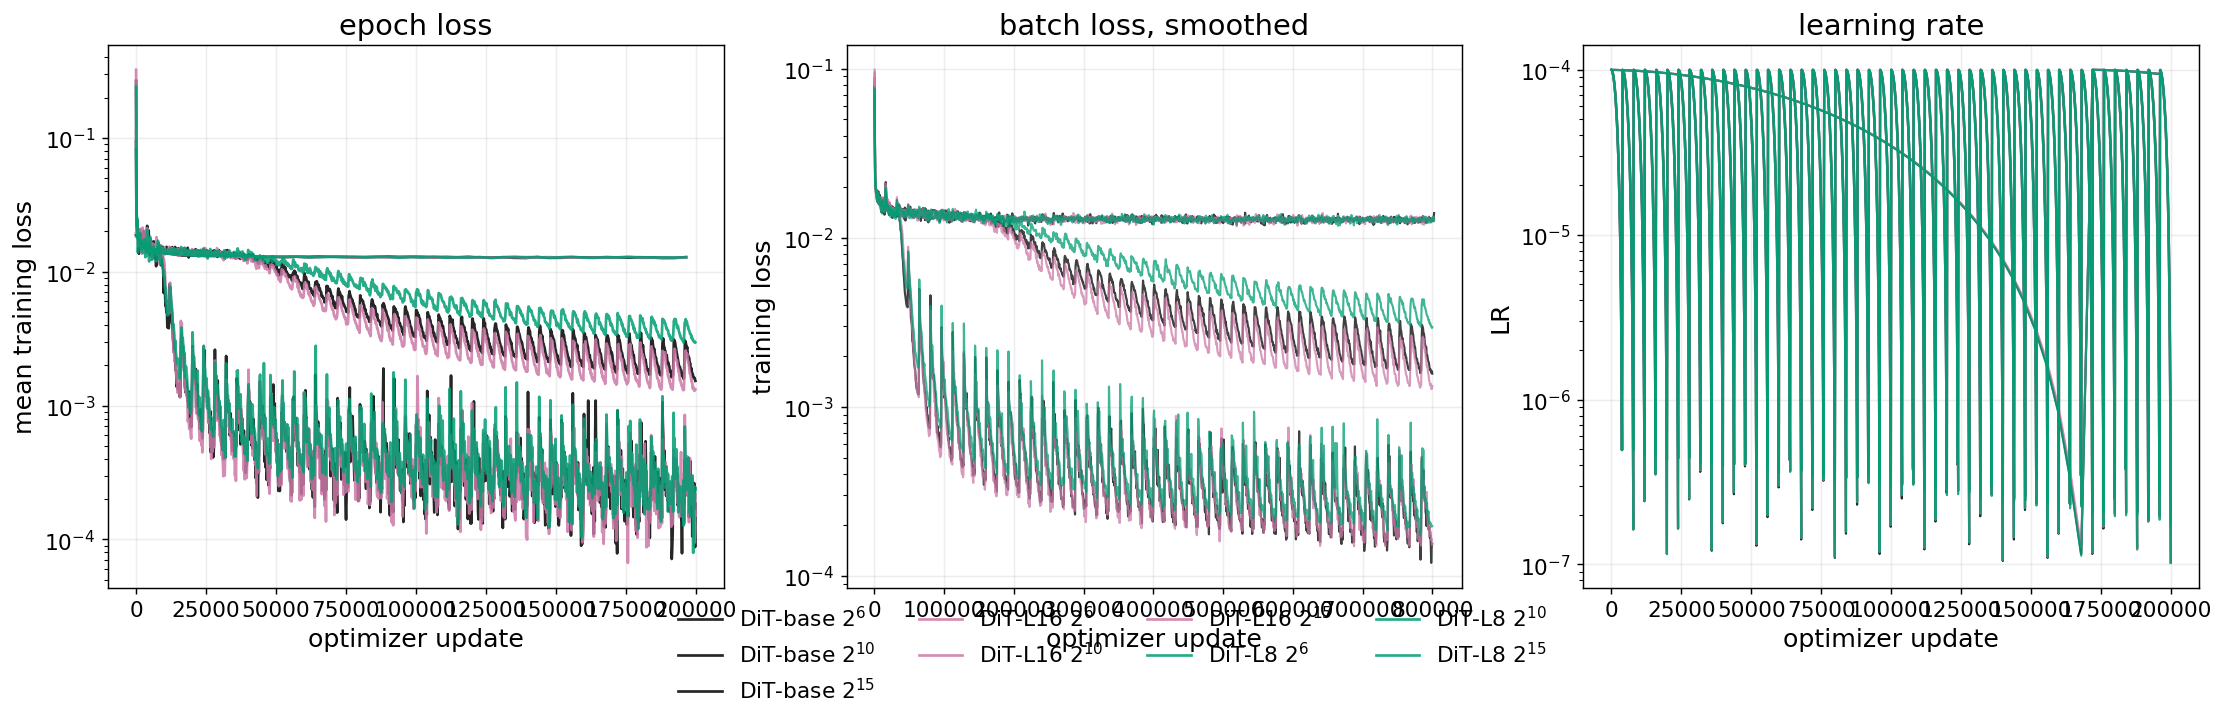

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_training_curves.png


In [4]:
def checkpoint_epoch(path: Path) -> int | None:
    m = re.search(r'checkpoint-epoch-(\d+)', str(path))
    return int(m.group(1)) if m else None


def metric_candidates(row: pd.Series) -> list[Path]:
    root = Path(str(row.get('checkpoint_dir', '') or ''))
    paths: list[Path] = []
    if root.exists():
        paths.extend(sorted(root.glob('metrics_epoch_*.json')))
        metrics_json = root / 'metrics.json'
        if metrics_json.exists():
            paths.append(metrics_json)
        for ckpt in sorted(root.glob('checkpoint-epoch-*')):
            paths.extend(sorted(ckpt.glob('metrics*.json')))
    return paths


def flatten_numeric(values: Any) -> np.ndarray:
    if values is None:
        return np.asarray([], dtype=float)
    out: list[float] = []

    def visit(x: Any) -> None:
        if x is None:
            return
        if isinstance(x, dict):
            for key in ('loss', 'value', 'mean', 'avg'):
                if key in x:
                    visit(x[key])
                    return
            return
        if isinstance(x, (list, tuple, np.ndarray)):
            for item in x:
                visit(item)
            return
        try:
            out.append(float(x))
        except (TypeError, ValueError):
            return

    visit(values)
    return np.asarray(out, dtype=float)


def read_latest_metrics(row: pd.Series) -> tuple[dict[str, Any], Path | None]:
    paths = metric_candidates(row)
    if not paths:
        return {}, None

    def score(path: Path) -> tuple[int, float]:
        epoch = checkpoint_epoch(path)
        return (epoch if epoch is not None else -1, path.stat().st_mtime)

    latest = max(paths, key=score)
    try:
        with latest.open() as f:
            return json.load(f), latest
    except Exception as exc:
        print('failed reading metrics:', latest, exc)
        return {}, latest


def downsample_xy(x: np.ndarray, y: np.ndarray, max_points: int = 1200) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    if len(x) <= max_points:
        return x, y
    idx = np.linspace(0, len(x) - 1, max_points, dtype=int)
    return x[idx], y[idx]


loss_by_run: dict[str, dict[str, Any]] = {}
loss_rows = []
if manifest_df.empty:
    display(Markdown('No manifest available; skipping loss audit.'))
else:
    for _, row in manifest_df.sort_values(['arch', 'dataset_size']).iterrows():
        metrics, metrics_path = read_latest_metrics(row)
        epoch_loss = flatten_numeric(metrics.get('epoch_loss'))
        batch_loss = flatten_numeric(metrics.get('loss', metrics.get('batch_loss')))
        epoch_lr = flatten_numeric(metrics.get('epoch_lr', metrics.get('lr')))
        run_name = str(row.get('run_name'))
        loss_by_run[run_name] = {
            'metrics': metrics,
            'metrics_path': metrics_path,
            'epoch_loss': epoch_loss,
            'batch_loss': batch_loss,
            'epoch_lr': epoch_lr,
        }
        loss_rows.append({
            'arch': row.get('arch'),
            'arch_label': row.get('arch_label'),
            'run_name': run_name,
            'dataset_tag': row.get('dataset_tag'),
            'dataset_size': int(row.get('dataset_size')) if pd.notna(row.get('dataset_size')) else np.nan,
            'steps_per_epoch': int(row.get('steps_per_epoch', 1) or 1),
            'metrics_path': rel(metrics_path) if metrics_path else None,
            'n_epoch_loss': len(epoch_loss),
            'final_epoch_loss': float(epoch_loss[-1]) if len(epoch_loss) else np.nan,
            'best_epoch_loss': float(np.nanmin(epoch_loss)) if len(epoch_loss) else np.nan,
            'n_batch_loss': len(batch_loss),
            'final_batch_loss': float(batch_loss[-1]) if len(batch_loss) else np.nan,
        })

    loss_df = pd.DataFrame(loss_rows).sort_values(['arch', 'dataset_size'])
    display(loss_df)

    plot_df = manifest_df[manifest_df['arch'].isin(LOSS_ARCHES) & manifest_df['dataset_tag'].isin(LOSS_TAGS)].copy()
    if plot_df.empty:
        plot_df = manifest_df.copy()

    if loss_df['n_epoch_loss'].sum() == 0 and loss_df['n_batch_loss'].sum() == 0:
        print('No training metrics JSON found yet.')
    else:
        fig, axes = plt.subplots(1, 3, figsize=(17, 5.0), constrained_layout=True)
        for _, row in plot_df.sort_values(['arch', 'dataset_size']).iterrows():
            run_name = str(row.get('run_name'))
            info = loss_by_run.get(run_name, {})
            label = f"{row.get('arch_label', arch_label(row.get('arch')))} {dataset_size_label(row['dataset_size'])}"
            color = DIT_ARCH_COLORS.get(str(row.get('arch')), '0.2')
            steps_per_epoch = max(1, int(row.get('steps_per_epoch', 1) or 1))

            epoch_loss = np.asarray(info.get('epoch_loss', []), dtype=float)
            if len(epoch_loss):
                x = np.arange(len(epoch_loss), dtype=float) * steps_per_epoch
                x, y = downsample_xy(x, epoch_loss)
                axes[0].plot(x, y, lw=1.5, color=color, alpha=0.85, label=label)

            batch_loss = np.asarray(info.get('batch_loss', []), dtype=float)
            if len(batch_loss):
                x = np.arange(len(batch_loss), dtype=float)
                y = batch_loss
                window = max(1, len(y) // 1200)
                if window > 1:
                    kernel = np.ones(window, dtype=float) / window
                    y = np.convolve(y, kernel, mode='valid')
                    x = x[:len(y)] + 0.5 * (window - 1)
                x, y = downsample_xy(x, y)
                axes[1].plot(x, y, lw=1.2, color=color, alpha=0.75, label=label)

            epoch_lr = np.asarray(info.get('epoch_lr', []), dtype=float)
            if len(epoch_lr):
                x = np.arange(len(epoch_lr), dtype=float) * steps_per_epoch
                x, y = downsample_xy(x, epoch_lr)
                axes[2].plot(x, y, lw=1.2, color=color, alpha=0.85, label=label)

        axes[0].set_title('epoch loss')
        axes[0].set_xlabel('optimizer update')
        axes[0].set_ylabel('mean training loss')
        axes[1].set_title('batch loss, smoothed')
        axes[1].set_xlabel('optimizer update')
        axes[1].set_ylabel('training loss')
        axes[2].set_title('learning rate')
        axes[2].set_xlabel('optimizer update')
        axes[2].set_ylabel('LR')
        for ax in axes:
            ax.grid(alpha=0.22)
            if ax.has_data():
                ax.set_yscale('log')
        handles, labels = axes[0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.10), ncol=min(4, len(labels)), frameon=False)
        out = QUICKCHECK_DIR / 'nf_generalize_fig2_dit_training_curves.png'
        QUICKCHECK_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(out, bbox_inches='tight')
        plt.show()
        print('wrote', out)

## Load Generated and Real Reference Slices

These cells load the DiT sample `.npz` files and the matching real CAMELS training slices from each run config. The load is capped for notebook responsiveness; increase `DIT_MAX_GENERATED` or `DIT_MAX_REAL_RAW_CUBES` if needed.


In [5]:
def npz_array_key(path: Path) -> str:
    with np.load(path) as data:
        return 'samples' if 'samples' in data.files else data.files[0]


def load_npz_array(path: Path) -> np.ndarray:
    with np.load(path) as data:
        key = 'samples' if 'samples' in data.files else data.files[0]
        arr = np.asarray(data[key], dtype=np.float32)
    if SIMDIFF_EVAL_AVAILABLE:
        return as_nchw(arr)
    if arr.ndim == 3:
        return arr[:, None, :, :]
    if arr.ndim == 4 and arr.shape[1] in (1, 3):
        return arr
    if arr.ndim == 4 and arr.shape[-1] in (1, 3):
        return np.moveaxis(arr, -1, 1)
    raise ValueError(f'Could not interpret generated array shape {arr.shape}')


def evenly_limit(arr: np.ndarray, limit: int | None) -> np.ndarray:
    arr = np.asarray(arr)
    if limit is None or len(arr) <= int(limit):
        return arr.copy()
    idx = np.linspace(0, len(arr) - 1, int(limit), dtype=int)
    return arr[idx].copy()


def config_path_for(row: pd.Series) -> Path:
    raw = str(row.get('config', '') or row.get('config_path', '') or '')
    if raw:
        path = Path(raw)
        return path if path.is_absolute() else PROJECT_DIR / path
    return PROJECT_DIR / 'local' / SWEEP_NAME / 'configs' / f"{row['run_name']}.yaml"


loaded: dict[str, dict[str, Any]] = {}
load_rows = []
if manifest_df.empty:
    display(Markdown('No manifest available; skipping generated/real loading.'))
elif not SIMDIFF_EVAL_AVAILABLE:
    display(Markdown(f'`simdiff_eval` unavailable, so real-reference diagnostics are skipped: `{SIMDIFF_EVAL_ERROR}`'))
else:
    for _, row in manifest_df.sort_values(['arch', 'dataset_size']).iterrows():
        sample_path = Path(row['sample_path_resolved'])
        if not sample_path.exists():
            continue
        cfg_path = config_path_for(row)
        try:
            generated = evenly_limit(load_npz_array(sample_path), MAX_GENERATED)
            raw_cap = min(int(row.get('n_train_simulations', MAX_REAL_RAW_CUBES) or MAX_REAL_RAW_CUBES), MAX_REAL_RAW_CUBES)
            real = as_nchw(load_real_from_config(cfg_path, max_raw_samples=raw_cap))
            run_name = str(row.get('run_name'))
            loaded[run_name] = {
                'spec': row,
                'real': real,
                'generated': generated,
                'sample_path': sample_path,
                'config_path': cfg_path,
            }
            load_rows.append({
                'arch': row.get('arch'),
                'arch_label': row.get('arch_label'),
                'run_name': run_name,
                'dataset_tag': row.get('dataset_tag'),
                'dataset_size': int(row.get('dataset_size')),
                'n_real_loaded': len(real),
                'n_generated_loaded': len(generated),
                'sample_path': rel(sample_path),
                'config_path': rel(cfg_path),
            })
        except Exception as exc:
            load_rows.append({
                'arch': row.get('arch'),
                'arch_label': row.get('arch_label'),
                'run_name': row.get('run_name'),
                'dataset_tag': row.get('dataset_tag'),
                'dataset_size': row.get('dataset_size'),
                'n_real_loaded': 0,
                'n_generated_loaded': 0,
                'error': repr(exc),
                'sample_path': rel(sample_path),
                'config_path': rel(cfg_path),
            })

loaded_df = pd.DataFrame(load_rows).sort_values(['arch', 'dataset_size']) if load_rows else pd.DataFrame()
display(loaded_df)
print('loaded DiT sample rows:', len(loaded))

,arch,arch_label,run_name,dataset_tag,dataset_size,n_real_loaded,n_generated_loaded,sample_path,config_path
0,dit_base,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,64,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
1,dit_base,DiT-base,nf_fig2_dit_base_d2p07_noaug_200k,d2p07,128,128,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
2,dit_base,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
3,dit_base,DiT-base,nf_fig2_dit_base_d2p09_noaug_200k,d2p09,512,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
4,dit_base,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
5,dit_base,DiT-base,nf_fig2_dit_base_d2p11_noaug_200k,d2p11,2048,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
6,dit_base,DiT-base,nf_fig2_dit_base_d2p12_noaug_200k,d2p12,4096,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
7,dit_base,DiT-base,nf_fig2_dit_base_d2p13_noaug_200k,d2p13,8192,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
8,dit_base,DiT-base,nf_fig2_dit_base_d2p14_noaug_200k,d2p14,16384,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...
9,dit_base,DiT-base,nf_fig2_dit_base_d2p15_noaug_200k,d2p15,32768,256,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...


loaded DiT sample rows: 30


## Generated Image Grids Across Data Size

A quick visual check across the DiT data-size sweep. These are not nearest-neighbor diagnostics; they just show what the generated fields look like as `N_2D` changes.


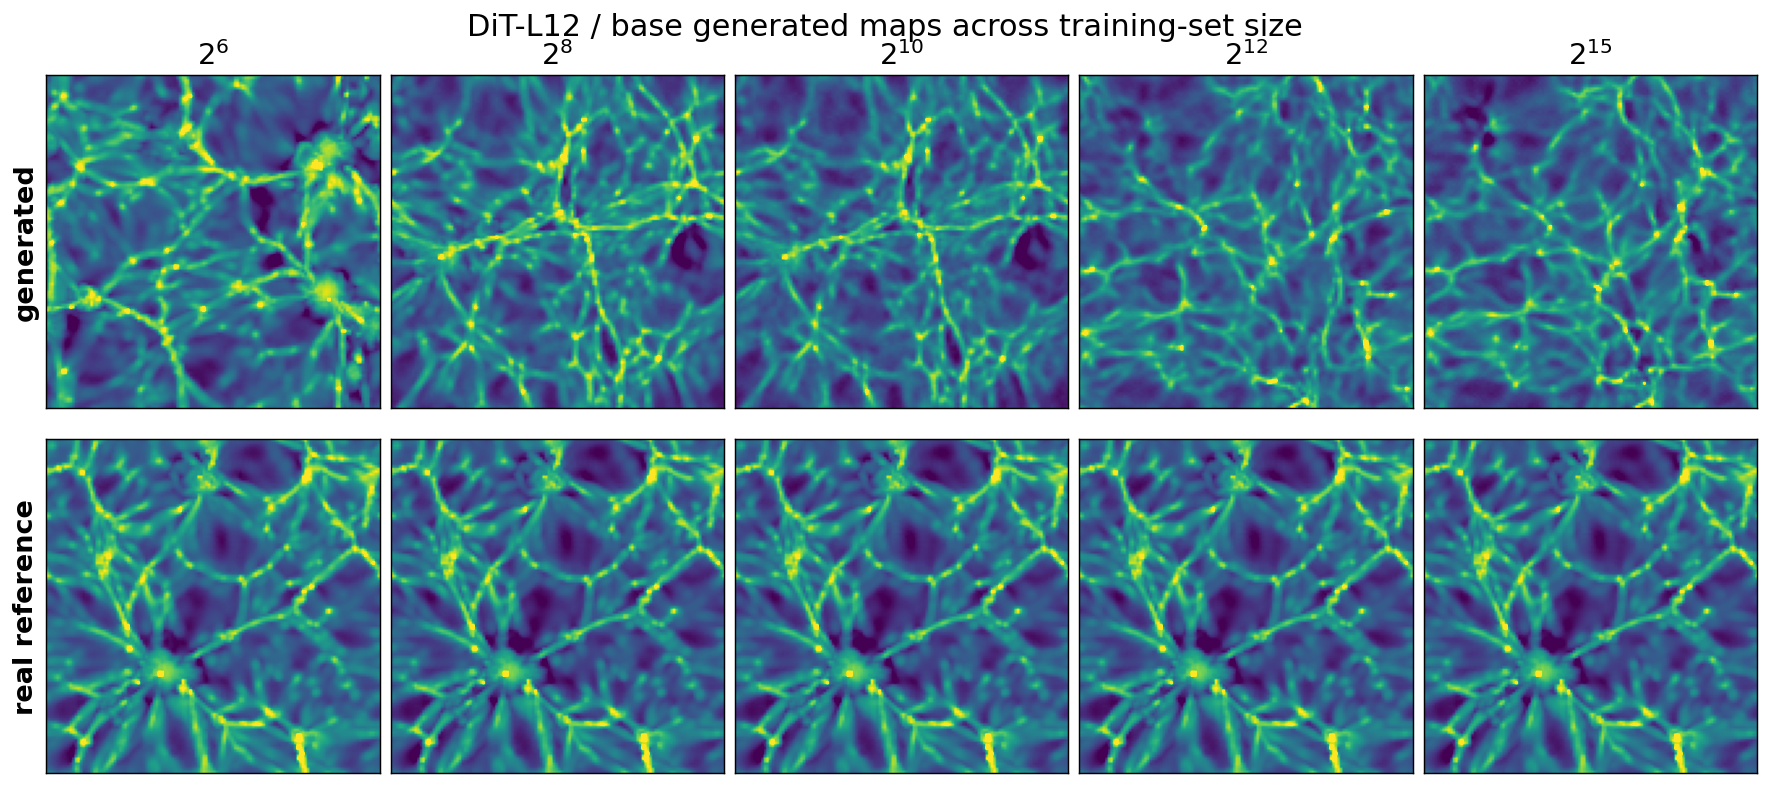

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_base_generated_image_grid.png


In [6]:
def choose_bundles(tags: list[str], max_count: int | None = None, arch: str | None = None) -> list[dict[str, Any]]:
    tag_set = set(tags)
    bundles = [
        b for b in loaded.values()
        if str(b['spec'].get('dataset_tag')) in tag_set
        and (arch is None or str(b['spec'].get('arch')) == arch)
    ]
    bundles = sorted(bundles, key=lambda b: int(b['spec']['dataset_size']))
    if not bundles:
        bundles = [b for b in loaded.values() if arch is None or str(b['spec'].get('arch')) == arch]
        bundles = sorted(bundles, key=lambda b: int(b['spec']['dataset_size']))
    if max_count is not None and len(bundles) > max_count:
        keep = np.linspace(0, len(bundles) - 1, max_count, dtype=int)
        bundles = [bundles[i] for i in keep]
    return bundles


def plot_dit_image_grid(sample_index: int = 0, tags: list[str] = IMAGE_TAGS, arch: str = IMAGE_ARCH) -> Path | None:
    if not loaded:
        display(Markdown('No loaded DiT samples available for image grid.'))
        return None
    bundles = choose_bundles(tags, max_count=6, arch=arch)
    if not bundles:
        display(Markdown(f'No selected bundles available for `{arch_label(arch)}` image grid.'))
        return None

    values = []
    for b in bundles:
        values.append(b['generated'][min(sample_index, len(b['generated']) - 1), 0].ravel())
        values.append(b['real'][0, 0].ravel())
    flat = np.concatenate(values)
    vmin = float(np.nanquantile(flat, 0.005))
    vmax = float(np.nanquantile(flat, 0.995))

    fig, axes = plt.subplots(2, len(bundles), figsize=(2.7 * len(bundles), 5.8), squeeze=False, constrained_layout=True)
    for col, b in enumerate(bundles):
        row = b['spec']
        gen_idx = min(sample_index, len(b['generated']) - 1)
        axes[0, col].imshow(b['generated'][gen_idx, 0], cmap='viridis', vmin=vmin, vmax=vmax)
        axes[1, col].imshow(b['real'][0, 0], cmap='viridis', vmin=vmin, vmax=vmax)
        axes[0, col].set_title(dataset_size_label(int(row['dataset_size'])))
        for ax in axes[:, col]:
            ax.set_xticks([])
            ax.set_yticks([])
    axes[0, 0].set_ylabel('generated', fontsize=15, fontweight='bold')
    axes[1, 0].set_ylabel('real reference', fontsize=15, fontweight='bold')
    fig.suptitle(f'{arch_label(arch)} generated maps across training-set size', y=1.03)
    out = QUICKCHECK_DIR / f'nf_generalize_fig2_{arch}_generated_image_grid.png'
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print('wrote', out)
    return out

image_grid_path = plot_dit_image_grid(sample_index=int(os.environ.get('DIT_IMAGE_SAMPLE_INDEX', '0')))

## One-point and P(k) Fidelity Across Data Size

These panels ask a different question from memorization: do the generated samples match real CAMELS summary statistics? Small-data runs can look good here by copying training slices, so read this together with the PCA/SSCD generalization curves.


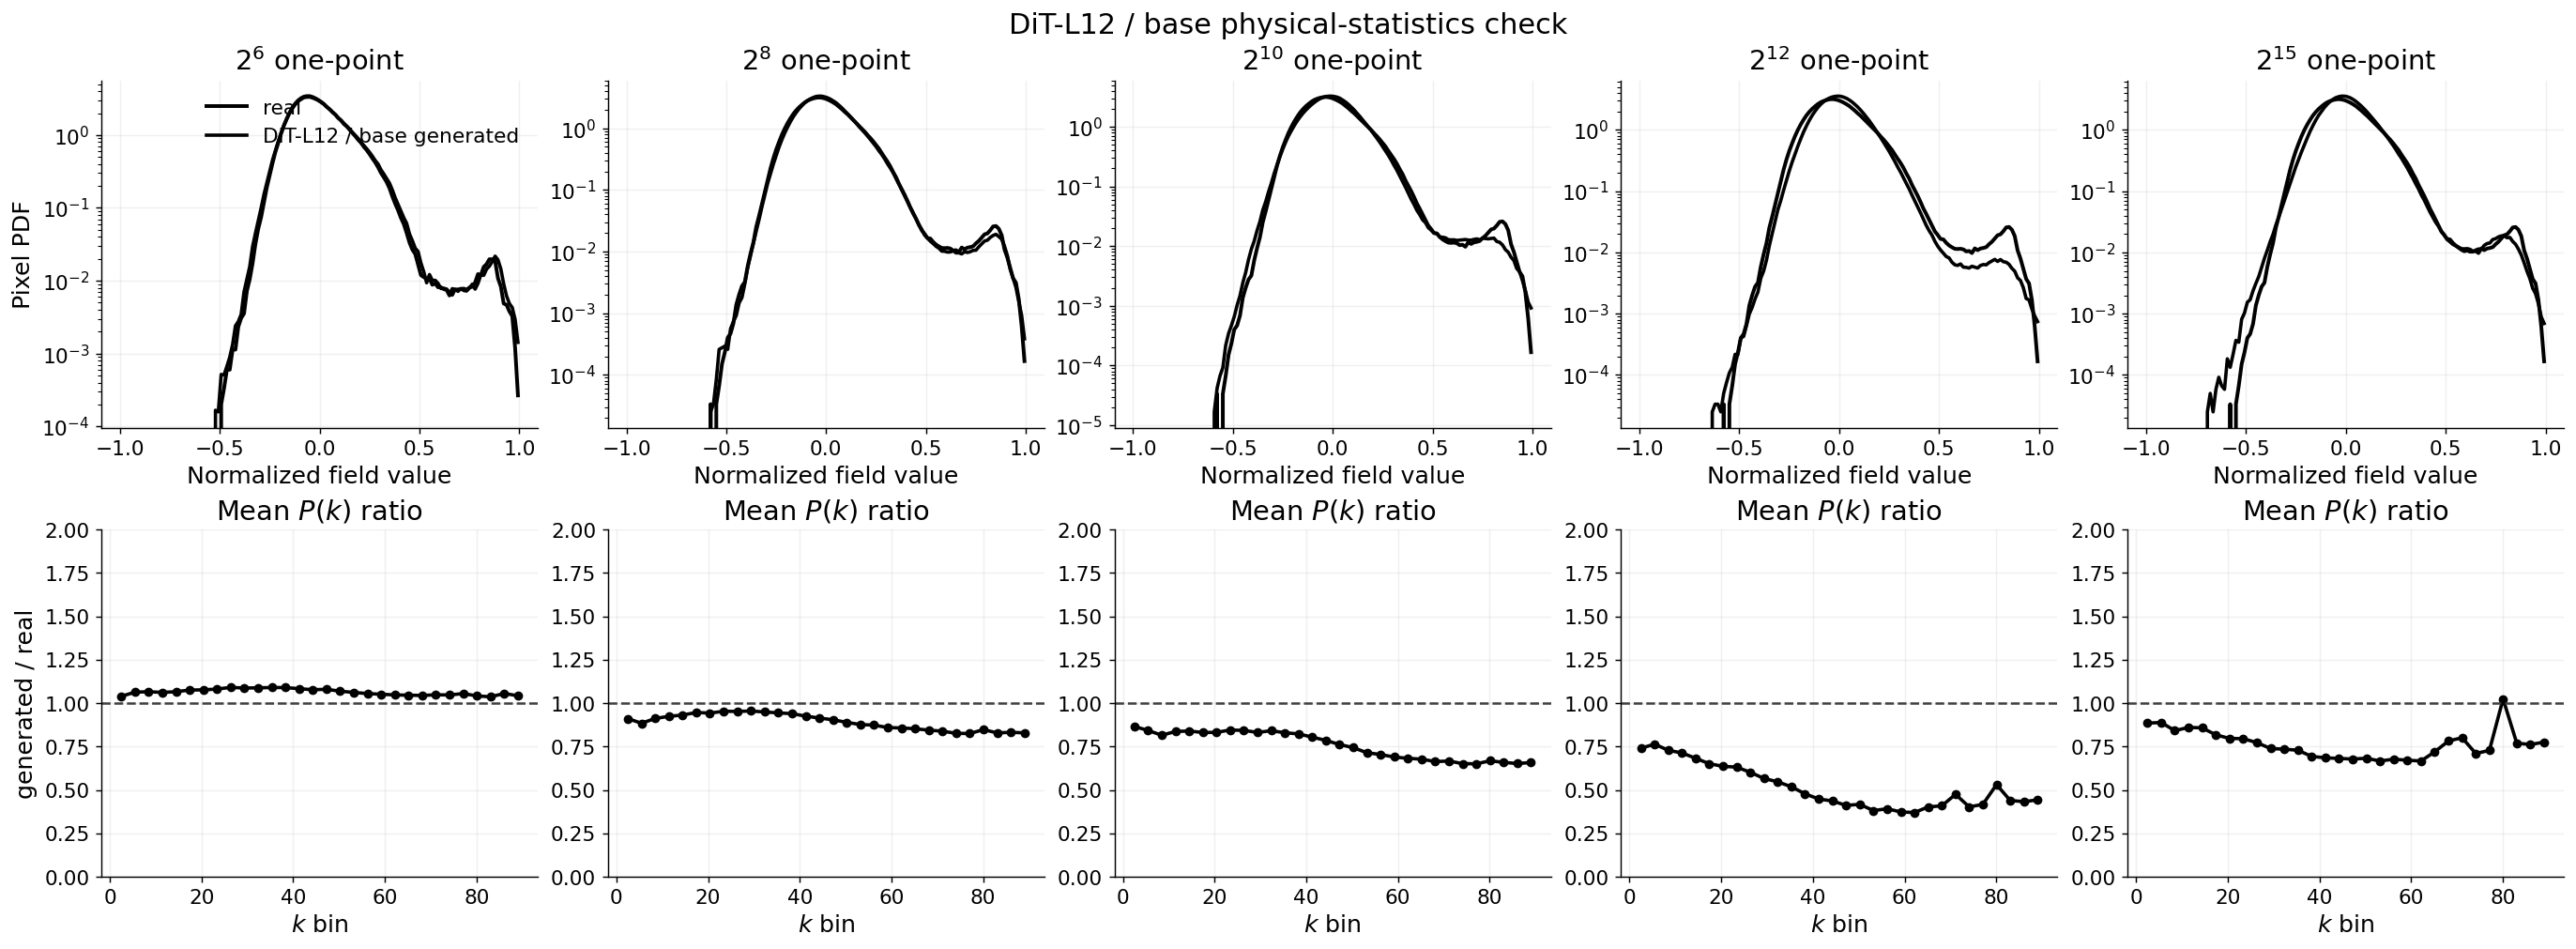

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_base_detail_onepoint_pk.png


,arch,arch_label,run_name,dataset_tag,dataset_size,sample_path,config_path,generated_shape,real_shape,generated_mean,...,generated_std,real_std,generated_min,real_min,generated_max,real_max,pk_ratio_median,pk_ratio_min,pk_ratio_max,max_abs_pk_ratio_minus_1
0,dit_base,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(64, 1, 128, 128)",0.001515,...,0.144054,0.139642,-0.521582,-0.497690,1.021988,0.999390,1.062763,1.036884,1.090996,0.090996
1,dit_base,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.001003,...,0.139239,0.145068,-0.578974,-0.576659,1.039144,0.999854,0.897039,0.825335,0.954949,0.174665
2,dit_base,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.002186,...,0.137682,0.145068,-0.590206,-0.576659,1.176072,0.999854,0.773799,0.650863,0.865652,0.349137
3,dit_base,DiT-base,nf_fig2_dit_base_d2p12_noaug_200k,d2p12,4096,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.010620,...,0.123772,0.145068,-0.635734,-0.576659,1.235085,0.999854,0.461724,0.370407,0.764235,0.629593
4,dit_base,DiT-base,nf_fig2_dit_base_d2p15_noaug_200k,d2p15,32768,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.011194,...,0.133368,0.145068,-0.696956,-0.576659,1.184920,0.999854,0.750615,0.667125,1.024748,0.332875


wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_base_fidelity_summary.csv


In [7]:
def plot_dit_onepoint_pk(tags: list[str] = DETAIL_TAGS, arch: str = DETAIL_ARCH) -> Path | None:
    if not loaded:
        display(Markdown('No loaded DiT samples available for one-point/P(k) plots.'))
        return None
    if not SIMDIFF_EVAL_AVAILABLE:
        display(Markdown('`simdiff_eval` unavailable; cannot compute one-point/P(k) diagnostics.'))
        return None

    bundles = choose_bundles(tags, max_count=5, arch=arch)
    if not bundles:
        display(Markdown(f'No selected `{arch_label(arch)}` bundles available for one-point/P(k) plots.'))
        return None

    n = len(bundles)
    fig, axes = plt.subplots(2, n, figsize=(max(4.2 * n, 8.6), 7.4), squeeze=False, constrained_layout=True)
    rows = []
    for col, bundle in enumerate(bundles):
        row = bundle['spec']
        real = bundle['real']
        generated = bundle['generated']

        rh = field_histogram(real, bins=140)
        gh = field_histogram(generated, bins=140)
        edges = np.asarray(rh['bin_edges'])
        centers = 0.5 * (edges[:-1] + edges[1:])
        axes[0, col].plot(centers, rh['hist'], color='black', lw=2.2, label='real')
        axes[0, col].plot(centers, gh['hist'], color=DIT_ARCH_COLORS.get(arch, '#0072B2'), lw=2.0, label=f'{arch_label(arch)} generated')
        axes[0, col].set_yscale('log')
        axes[0, col].set_title(f"{dataset_size_label(int(row['dataset_size']))} one-point")
        axes[0, col].set_xlabel('Normalized field value')
        if col == 0:
            axes[0, col].set_ylabel('Pixel PDF')
            axes[0, col].legend(frameon=False, loc='upper right')

        pk_real, kbins = batch_power_spectra(real, nbins=PK_NBINS)
        pk_gen, _ = batch_power_spectra(generated, nbins=PK_NBINS)
        mean_real = np.clip(np.nanmean(pk_real, axis=0), 1e-30, None)
        mean_gen = np.nanmean(pk_gen, axis=0)
        ratio = mean_gen / mean_real
        axes[1, col].plot(kbins, ratio, marker='o', ms=4.4, lw=2.0, color=DIT_ARCH_COLORS.get(arch, '#0072B2'))
        axes[1, col].axhline(1.0, color='0.25', ls='--', lw=1.4)
        upper = max(2.0, float(np.nanquantile(ratio, 0.98)) * 1.15 if np.isfinite(ratio).any() else 2.0)
        axes[1, col].set_ylim(0, upper)
        axes[1, col].set_title('Mean $P(k)$ ratio')
        axes[1, col].set_xlabel('$k$ bin')
        if col == 0:
            axes[1, col].set_ylabel('generated / real')

        finite = np.isfinite(ratio)
        sample_path = bundle.get('sample_path')
        config_path = bundle.get('config_path')
        rows.append({
            'arch': row.get('arch'),
            'arch_label': row.get('arch_label'),
            'run_name': row.get('run_name'),
            'dataset_tag': row.get('dataset_tag'),
            'dataset_size': int(row['dataset_size']),
            'sample_path': rel(sample_path),
            'config_path': rel(config_path),
            'generated_shape': tuple(generated.shape),
            'real_shape': tuple(real.shape),
            'generated_mean': float(np.nanmean(generated)),
            'real_mean': float(np.nanmean(real)),
            'generated_std': float(np.nanstd(generated)),
            'real_std': float(np.nanstd(real)),
            'generated_min': float(np.nanmin(generated)),
            'real_min': float(np.nanmin(real)),
            'generated_max': float(np.nanmax(generated)),
            'real_max': float(np.nanmax(real)),
            'pk_ratio_median': float(np.nanmedian(ratio[finite])) if finite.any() else np.nan,
            'pk_ratio_min': float(np.nanmin(ratio[finite])) if finite.any() else np.nan,
            'pk_ratio_max': float(np.nanmax(ratio[finite])) if finite.any() else np.nan,
            'max_abs_pk_ratio_minus_1': float(np.nanmax(np.abs(ratio[finite] - 1.0))) if finite.any() else np.nan,
        })

        for ax in axes[:, col]:
            ax.grid(alpha=0.18)
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)

    fig.suptitle(f'{arch_label(arch)} physical-statistics check', y=1.03)
    out = QUICKCHECK_DIR / f'nf_generalize_fig2_{arch}_detail_onepoint_pk.png'
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print('wrote', out)

    fidelity_summary = pd.DataFrame(rows).sort_values(['arch', 'dataset_size'])
    display(fidelity_summary)
    table_out = TABLE_DIR / f'nf_generalize_fig2_{arch}_fidelity_summary.csv'
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    fidelity_summary.to_csv(table_out, index=False)
    print('wrote', table_out)
    return out

fidelity_plot_path = plot_dit_onepoint_pk()

## Focused DiT Small-Data Sanity Checks

The DiT curves show suspicious small-data behavior, especially for the deeper models. This section compares the same $N_{2D}=2^6,2^7,2^8,2^9,2^{10}$ runs across DiT-L8, DiT-L12/base, and DiT-L16.

The goal is to separate three possibilities:
1. **real architecture behavior:** deeper DiTs genuinely leave the training-neighbor regime earlier;
2. **metric-specific artifact:** PCA and SSCD disagree, so the effect depends on the embedding;
3. **bad-generation artifact:** loss, images, one-point PDFs, or $P(k)$ look poor even when the generalization score is high.

,feature,run_name,arch,arch_label,dataset_tag,dataset_size,n_generated,gen_gl_q90,gen_gl_q95,gen_gl_q99,gen_copy_fraction_q90,gen_copy_fraction_q95,gen_copy_fraction_q99,threshold_q90,threshold_q95,threshold_q99,gen_nn_median,gen_nn_q95
10,PCA,nf_fig2_dit_l8_d2p06_noaug_200k,dit_l8,DiT-L8,d2p06,64,512,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.718470,0.725829,0.734308,0.999916,0.999936
25,SSCD,nf_fig2_dit_l8_d2p06_noaug_200k,dit_l8,DiT-L8,d2p06,64,512,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.906874,0.917692,0.923196,0.998891,0.999413
11,PCA,nf_fig2_dit_l8_d2p07_noaug_200k,dit_l8,DiT-L8,d2p07,128,512,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.947715,0.955543,0.965666,0.999787,0.999839
26,SSCD,nf_fig2_dit_l8_d2p07_noaug_200k,dit_l8,DiT-L8,d2p07,128,512,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.941889,0.955569,0.967376,0.996255,0.998406
12,PCA,nf_fig2_dit_l8_d2p08_noaug_200k,dit_l8,DiT-L8,d2p08,256,512,0.011719,0.011719,0.013672,0.988281,0.988281,0.986328,0.967740,0.970366,0.979813,0.999062,0.999441
27,SSCD,nf_fig2_dit_l8_d2p08_noaug_200k,dit_l8,DiT-L8,d2p08,256,512,0.218750,0.462891,0.656250,0.781250,0.537109,0.343750,0.971421,0.981710,0.987798,0.983165,0.993558
13,PCA,nf_fig2_dit_l8_d2p09_noaug_200k,dit_l8,DiT-L8,d2p09,512,512,0.083984,0.107422,0.140625,0.916016,0.892578,0.859375,0.959951,0.966680,0.975210,0.993242,0.997277
28,SSCD,nf_fig2_dit_l8_d2p09_noaug_200k,dit_l8,DiT-L8,d2p09,512,512,0.794922,0.931641,1.000000,0.205078,0.068359,0.000000,0.967146,0.976412,0.986444,0.945195,0.978064
14,PCA,nf_fig2_dit_l8_d2p10_noaug_200k,dit_l8,DiT-L8,d2p10,1024,512,0.687500,0.845703,1.000000,0.312500,0.154297,0.000000,0.964907,0.976933,0.990506,0.943687,0.983569
29,SSCD,nf_fig2_dit_l8_d2p10_noaug_200k,dit_l8,DiT-L8,d2p10,1024,512,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.971215,0.983245,0.992197,0.853811,0.947513


wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_small_data_pca_sscd_comparison.csv


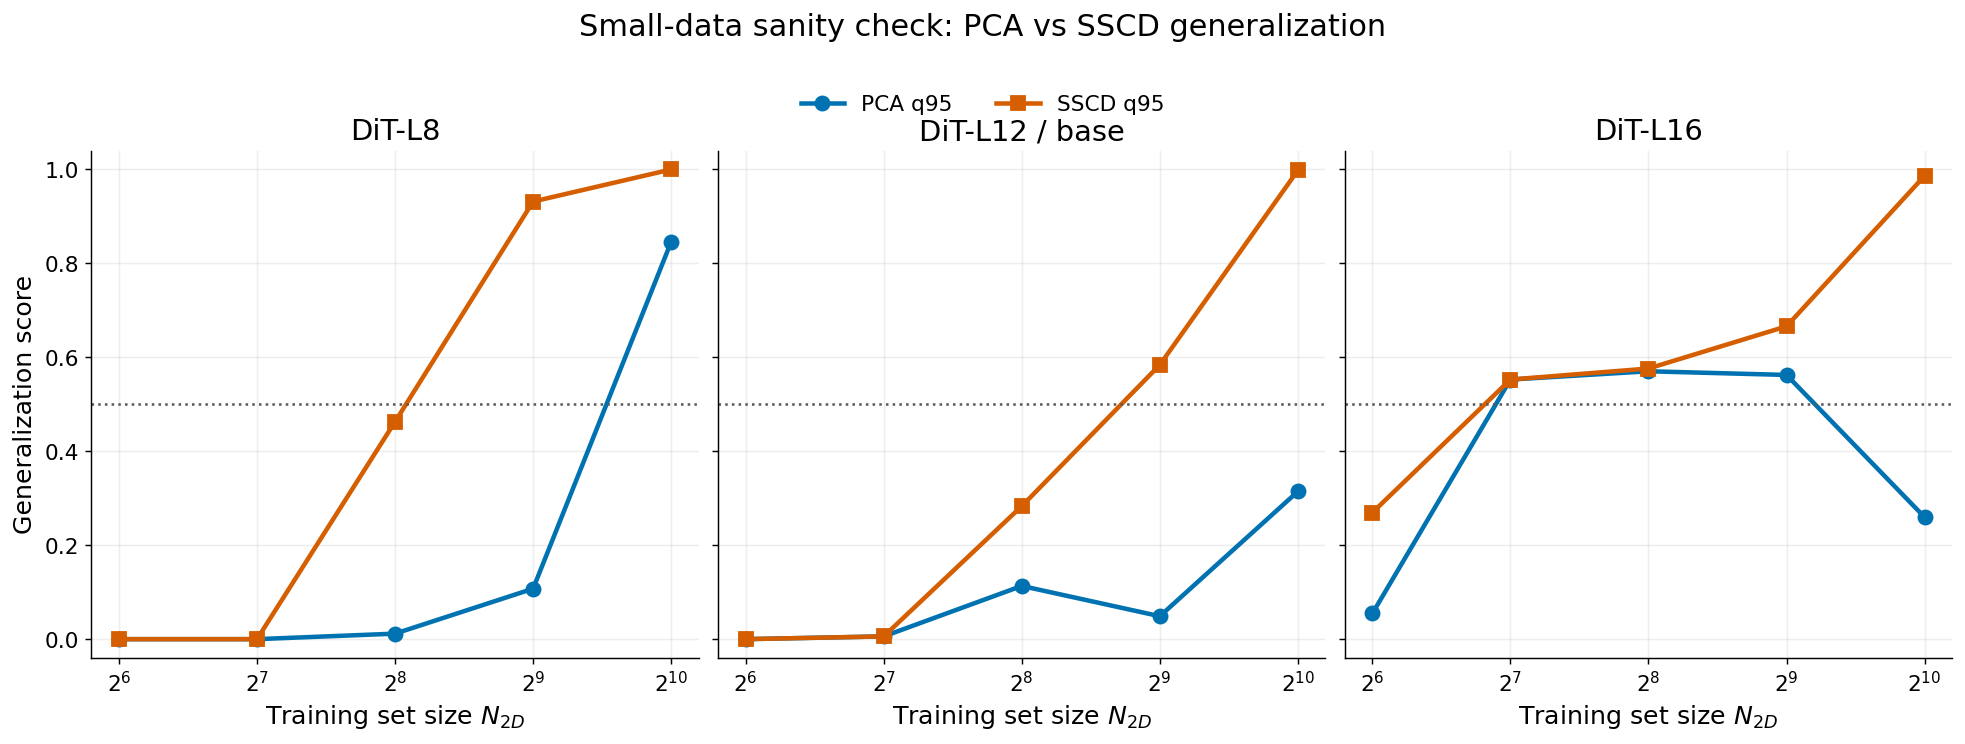

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_small_data_pca_sscd_q95_by_depth.png


In [8]:
SANITY_ARCHES = parse_csv_env('DIT_SANITY_ARCHES', 'dit_l8,dit_base,dit_l16')
SANITY_TAGS = parse_csv_env('DIT_SANITY_TAGS', 'd2p06,d2p07,d2p08,d2p09,d2p10')
SANITY_SAMPLE_INDEX = int(os.environ.get('DIT_SANITY_SAMPLE_INDEX', '0'))


def small_data_metric_comparison(
    arches: list[str] = SANITY_ARCHES,
    tags: list[str] = SANITY_TAGS,
) -> pd.DataFrame:
    frames = []
    for feature, metrics in [('PCA', pca_metrics), ('SSCD', sscd_metrics)]:
        if metrics.empty:
            continue
        tmp = ensure_arch_columns(metrics)
        if 'dataset_tag' not in tmp.columns:
            continue
        sub = tmp[tmp['arch'].astype(str).isin(arches) & tmp['dataset_tag'].astype(str).isin(tags)].copy()
        if sub.empty:
            continue
        keep = [
            'run_name', 'arch', 'arch_label', 'dataset_tag', 'dataset_size',
            'n_generated', 'n_train',
            'gen_gl_q90', 'gen_gl_q95', 'gen_gl_q99',
            'gen_copy_fraction_q90', 'gen_copy_fraction_q95', 'gen_copy_fraction_q99',
            'threshold_q90', 'threshold_q95', 'threshold_q99',
            'gen_nn_median', 'gen_nn_q95',
        ]
        sub = sub[[c for c in keep if c in sub.columns]]
        sub.insert(0, 'feature', feature)
        frames.append(sub)

    if not frames:
        display(Markdown('No PCA/SSCD metrics found for the small-data sanity check.'))
        return pd.DataFrame()

    comp = pd.concat(frames, ignore_index=True)
    comp['arch'] = comp['arch'].astype(str).replace({'dit': 'dit_base'})
    comp['arch_order'] = comp['arch'].map({a: i for i, a in enumerate(DIT_ARCH_ORDER)}).fillna(999)
    comp = comp.sort_values(['arch_order', 'dataset_size', 'feature']).drop(columns=['arch_order'])
    display(comp)

    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    out = TABLE_DIR / 'nf_generalize_fig2_dit_small_data_pca_sscd_comparison.csv'
    comp.to_csv(out, index=False)
    print('wrote', out)
    return comp


small_data_metric_comparison_df = small_data_metric_comparison()

if not small_data_metric_comparison_df.empty and 'gen_gl_q95' in small_data_metric_comparison_df.columns:
    valid_arches = [a for a in SANITY_ARCHES if a in set(small_data_metric_comparison_df['arch'].astype(str))]
    fig, axes = plt.subplots(1, len(valid_arches), figsize=(5.0 * max(1, len(valid_arches)), 4.8), sharey=True, constrained_layout=True)
    if len(valid_arches) == 1:
        axes = [axes]
    for ax, arch in zip(axes, valid_arches):
        arch_df = small_data_metric_comparison_df[small_data_metric_comparison_df['arch'].astype(str) == arch].copy()
        for feature, color, marker in [('PCA', '#0072B2', 'o'), ('SSCD', '#D55E00', 's')]:
            sub = arch_df[arch_df['feature'] == feature].sort_values('dataset_size')
            if sub.empty:
                continue
            ax.plot(
                sub['dataset_size'], sub['gen_gl_q95'],
                marker=marker, ms=7.8, lw=2.5, color=color,
                label=f'{feature} q95',
            )
        ticks = sorted(arch_df['dataset_size'].dropna().astype(int).unique())
        ax.axhline(0.5, color='0.35', lw=1.4, ls=':')
        ax.set_xscale('log', base=2)
        ax.set_xticks(ticks)
        ax.set_xticklabels([dataset_size_label(t) for t in ticks])
        ax.set_ylim(-0.04, 1.04)
        ax.set_title(arch_label(arch))
        ax.set_xlabel(r'Training set size $N_{2D}$')
        ax.grid(alpha=0.22)
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    axes[0].set_ylabel('Generalization score')
    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.06), ncol=2, frameon=False)
    fig.suptitle('Small-data sanity check: PCA vs SSCD generalization', y=1.16)
    out = QUICKCHECK_DIR / 'nf_generalize_fig2_dit_small_data_pca_sscd_q95_by_depth.png'
    QUICKCHECK_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print('wrote', out)
else:
    display(Markdown('No `gen_gl_q95` column available for focused PCA-vs-SSCD plot.'))

### DiT-L16 generated maps for $2^6$--$2^{10}$

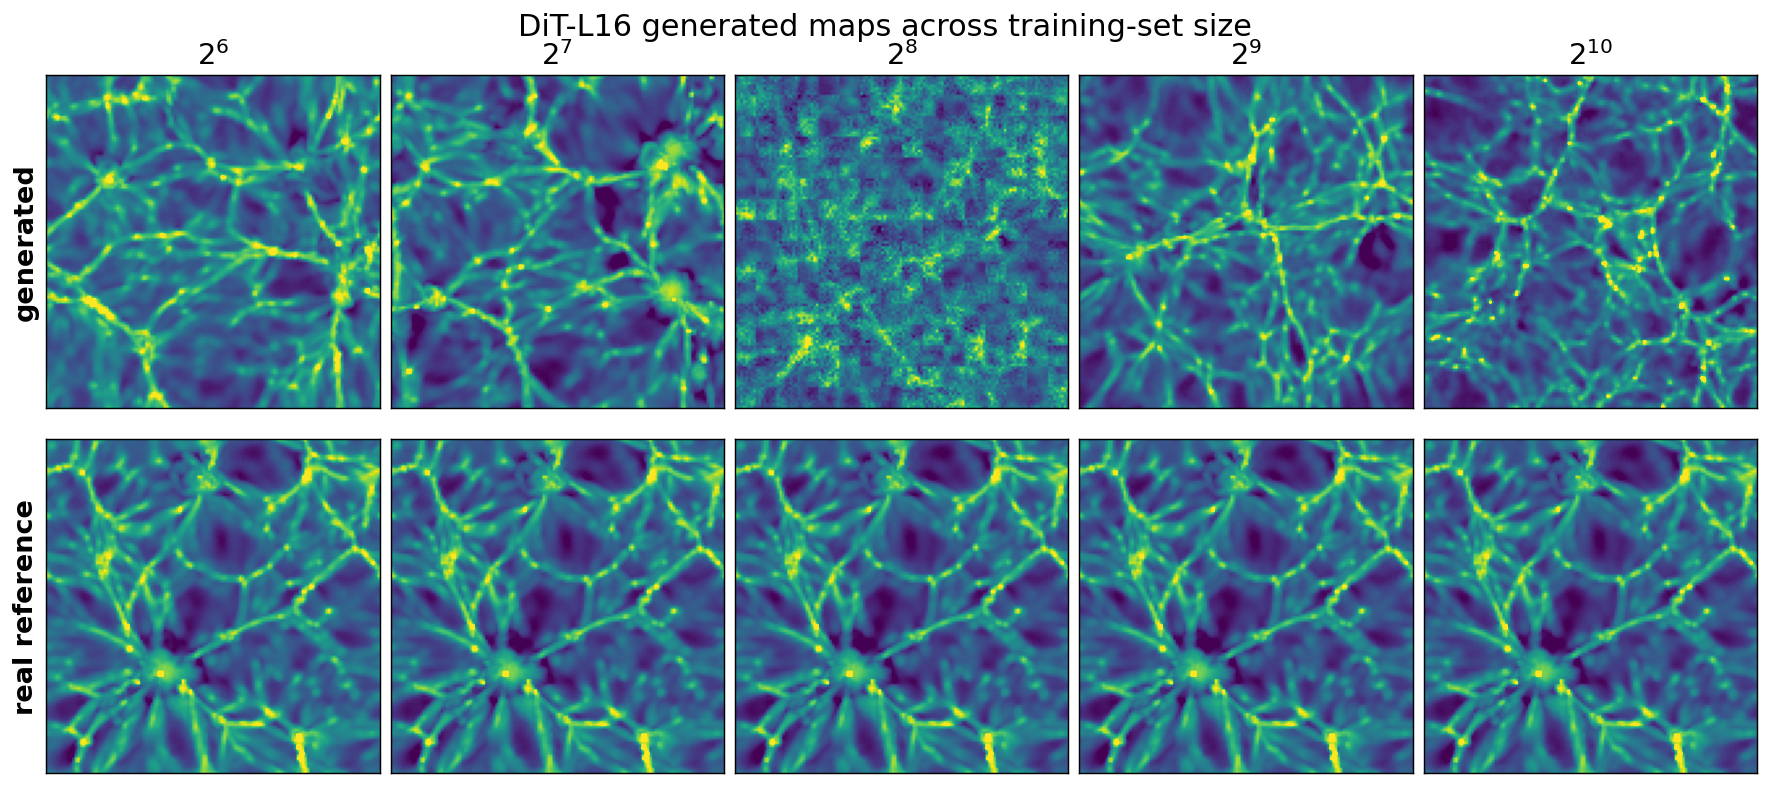

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_l16_generated_image_grid.png


In [9]:
small_data_image_paths = {}
for arch in SANITY_ARCHES:
    display(Markdown(f'### {arch_label(arch)} generated maps for $2^6$--$2^{{10}}$'))
    small_data_image_paths[arch] = plot_dit_image_grid(
        sample_index=SANITY_SAMPLE_INDEX,
        tags=SANITY_TAGS,
        arch=arch,
    )

### DiT-L8 one-point PDF and $P(k)$ for $2^6$--$2^{10}$

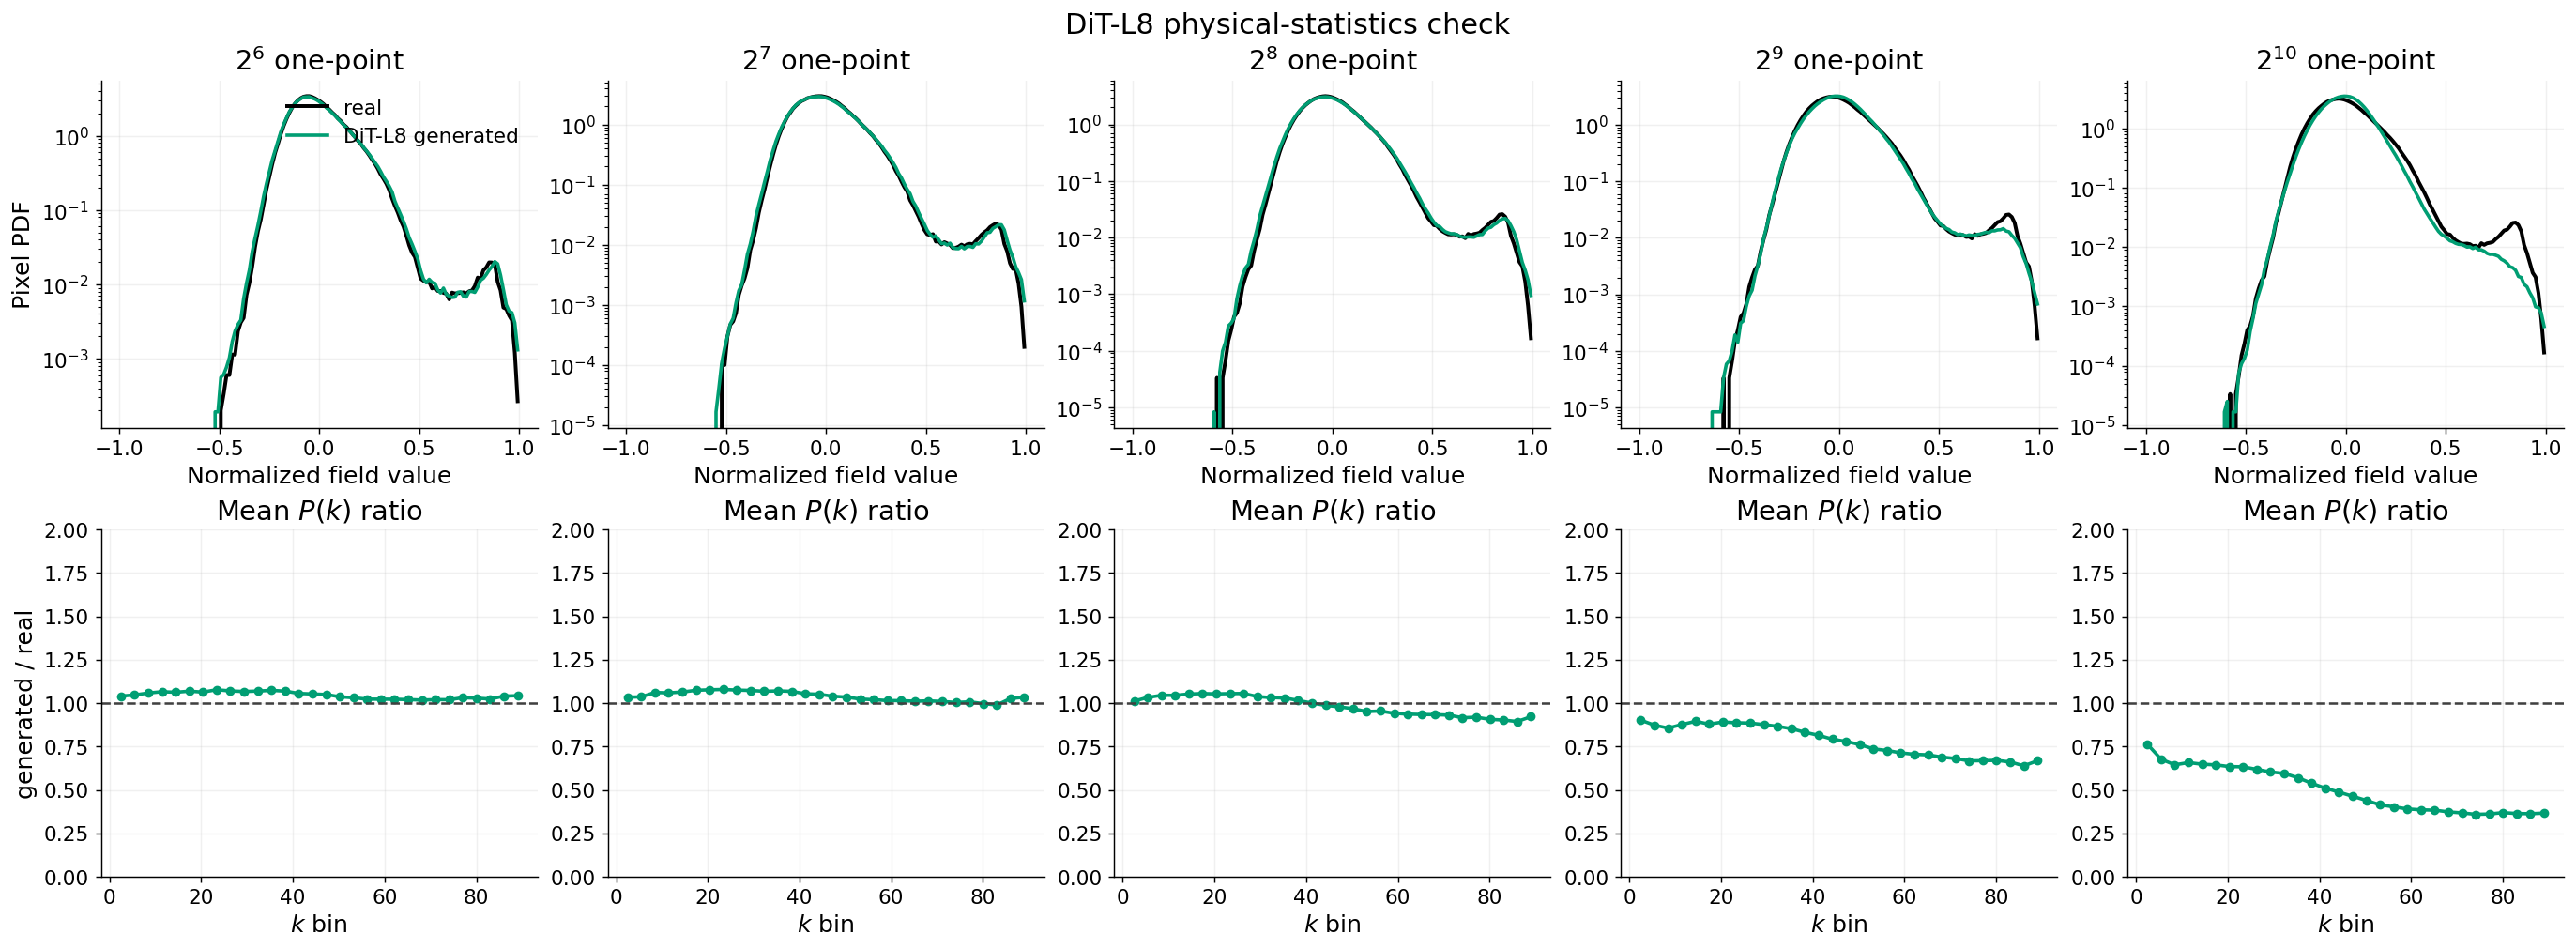

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_l8_detail_onepoint_pk.png


,arch,arch_label,run_name,dataset_tag,dataset_size,sample_path,config_path,generated_shape,real_shape,generated_mean,...,generated_std,real_std,generated_min,real_min,generated_max,real_max,pk_ratio_median,pk_ratio_min,pk_ratio_max,max_abs_pk_ratio_minus_1
0,dit_l8,DiT-L8,nf_fig2_dit_l8_d2p06_noaug_200k,d2p06,64,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(64, 1, 128, 128)",-0.001496,...,0.143351,0.139642,-0.523787,-0.497690,1.018528,0.999390,1.045188,1.017885,1.077619,0.077619
1,dit_l8,DiT-L8,nf_fig2_dit_l8_d2p07_noaug_200k,d2p07,128,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(128, 1, 128, 128)",-0.002397,...,0.149735,0.146381,-0.552430,-0.522376,1.028329,0.999967,1.035777,0.989774,1.079211,0.079211
2,dit_l8,DiT-L8,nf_fig2_dit_l8_d2p08_noaug_200k,d2p08,256,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",-0.002722,...,0.148006,0.145068,-0.593452,-0.576659,1.039513,0.999854,0.983186,0.894494,1.055897,0.105506
3,dit_l8,DiT-L8,nf_fig2_dit_l8_d2p09_noaug_200k,d2p09,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.003032,...,0.139035,0.145068,-0.642315,-0.576659,1.119343,0.999854,0.786317,0.639493,0.902144,0.360507
4,dit_l8,DiT-L8,nf_fig2_dit_l8_d2p10_noaug_200k,d2p10,1024,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",-0.000944,...,0.124785,0.145068,-0.608520,-0.576659,1.167196,0.999854,0.476087,0.360019,0.763689,0.639981


wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_l8_fidelity_summary.csv


### DiT-L12 / base one-point PDF and $P(k)$ for $2^6$--$2^{10}$

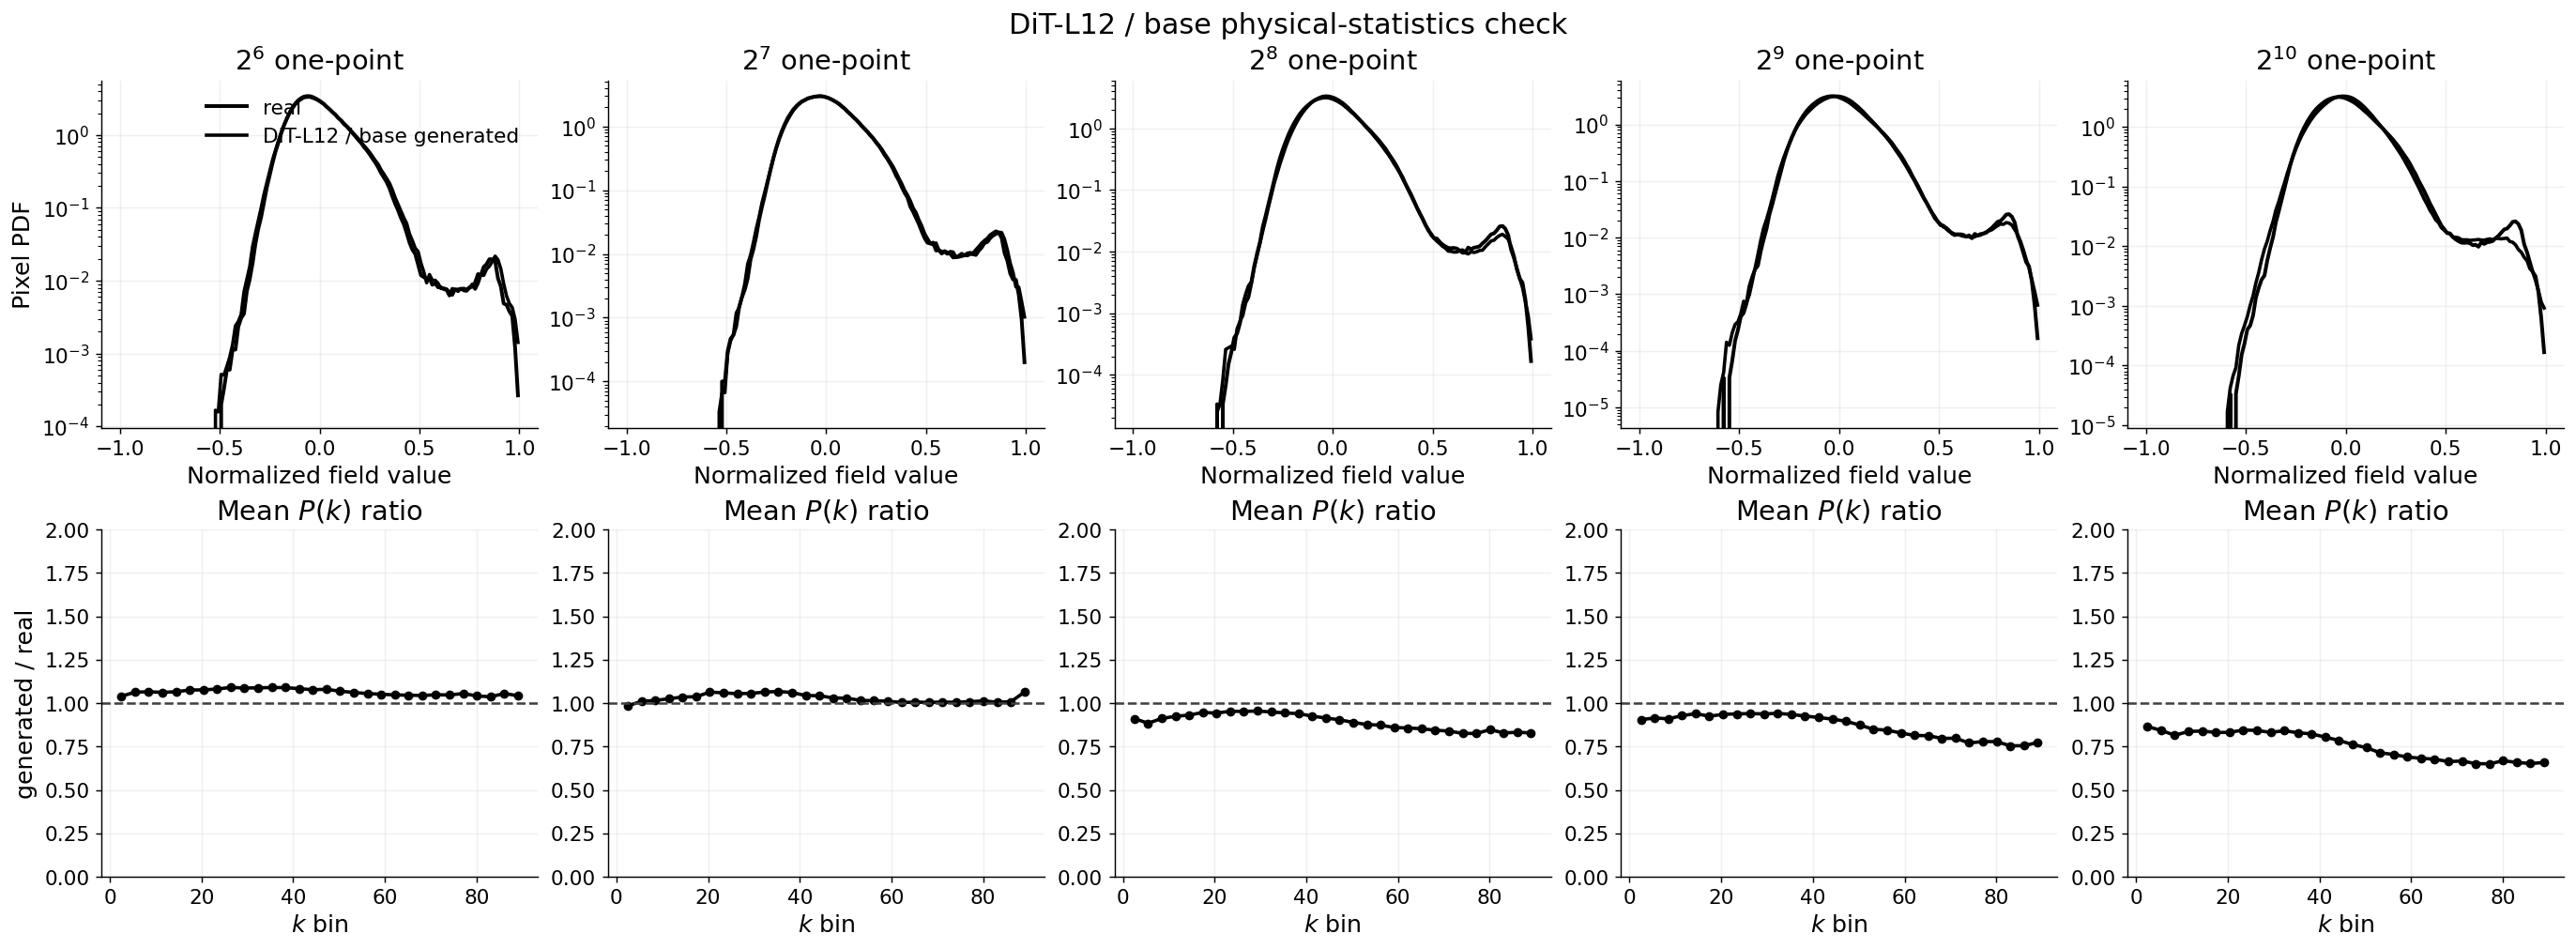

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_base_detail_onepoint_pk.png


,arch,arch_label,run_name,dataset_tag,dataset_size,sample_path,config_path,generated_shape,real_shape,generated_mean,...,generated_std,real_std,generated_min,real_min,generated_max,real_max,pk_ratio_median,pk_ratio_min,pk_ratio_max,max_abs_pk_ratio_minus_1
0,dit_base,DiT-base,nf_fig2_dit_base_d2p06_noaug_200k,d2p06,64,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(64, 1, 128, 128)",0.001515,...,0.144054,0.139642,-0.521582,-0.497690,1.021988,0.999390,1.062763,1.036884,1.090996,0.090996
1,dit_base,DiT-base,nf_fig2_dit_base_d2p07_noaug_200k,d2p07,128,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(128, 1, 128, 128)",0.001203,...,0.147754,0.146381,-0.537181,-0.522376,1.027032,0.999967,1.021063,0.984686,1.067377,0.067377
2,dit_base,DiT-base,nf_fig2_dit_base_d2p08_noaug_200k,d2p08,256,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.001003,...,0.139239,0.145068,-0.578974,-0.576659,1.039144,0.999854,0.897039,0.825335,0.954949,0.174665
3,dit_base,DiT-base,nf_fig2_dit_base_d2p09_noaug_200k,d2p09,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.002409,...,0.142689,0.145068,-0.612913,-0.576659,1.070825,0.999854,0.900342,0.754678,0.941299,0.245322
4,dit_base,DiT-base,nf_fig2_dit_base_d2p10_noaug_200k,d2p10,1024,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.002186,...,0.137682,0.145068,-0.590206,-0.576659,1.176072,0.999854,0.773799,0.650863,0.865652,0.349137


wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_base_fidelity_summary.csv


### DiT-L16 one-point PDF and $P(k)$ for $2^6$--$2^{10}$

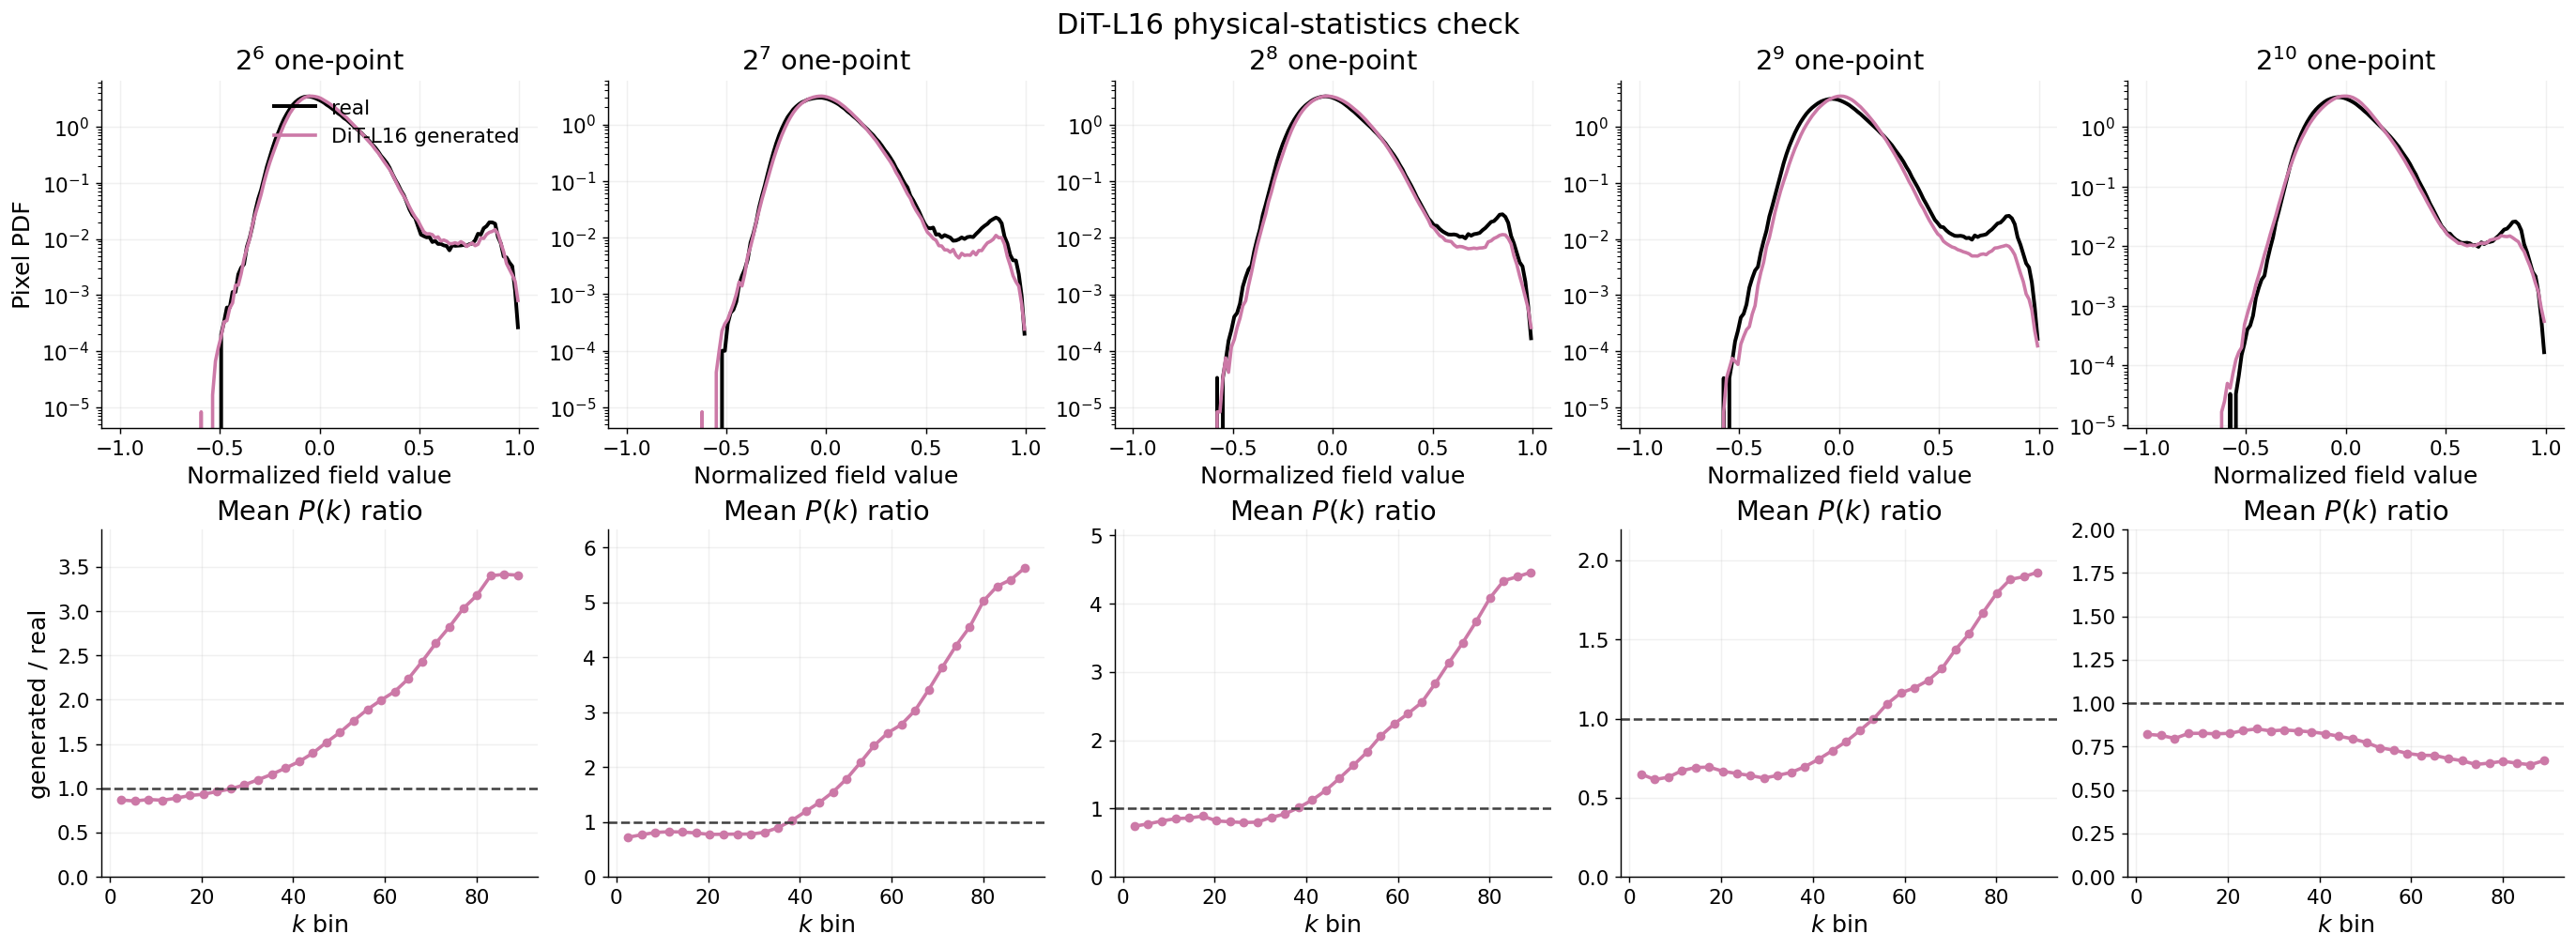

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_l16_detail_onepoint_pk.png


,arch,arch_label,run_name,dataset_tag,dataset_size,sample_path,config_path,generated_shape,real_shape,generated_mean,...,generated_std,real_std,generated_min,real_min,generated_max,real_max,pk_ratio_median,pk_ratio_min,pk_ratio_max,max_abs_pk_ratio_minus_1
0,dit_l16,DiT-L16,nf_fig2_dit_l16_d2p06_noaug_200k,d2p06,64,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(64, 1, 128, 128)",0.007052,...,0.134576,0.139642,-0.593544,-0.497690,1.015928,0.999390,1.457980,0.856197,3.415516,2.415516
1,dit_l16,DiT-L16,nf_fig2_dit_l16_d2p07_noaug_200k,d2p07,128,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(128, 1, 128, 128)",0.001020,...,0.135042,0.146381,-0.615990,-0.522376,1.023849,0.999967,1.449158,0.720181,5.621243,4.621243
2,dit_l16,DiT-L16,nf_fig2_dit_l16_d2p08_noaug_200k,d2p08,256,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.005405,...,0.134874,0.145068,-0.576098,-0.576659,1.098297,0.999854,1.356366,0.741449,4.461201,3.461201
3,dit_l16,DiT-L16,nf_fig2_dit_l16_d2p09_noaug_200k,d2p09,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.016305,...,0.123633,0.145068,-0.578581,-0.576659,1.061621,0.999854,0.826105,0.614720,1.924705,0.924705
4,dit_l16,DiT-L16,nf_fig2_dit_l16_d2p10_noaug_200k,d2p10,1024,results/nf_generalize_fig2_dit/samples/nf_fig2...,local/nf_generalize_fig2_dit/configs/nf_fig2_d...,"(512, 1, 128, 128)","(256, 1, 128, 128)",0.005886,...,0.136772,0.145068,-0.615755,-0.576659,1.108765,0.999854,0.796065,0.645618,0.852125,0.354382


wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_l16_fidelity_summary.csv


In [10]:
small_data_fidelity_paths = {}
for arch in SANITY_ARCHES:
    display(Markdown(f'### {arch_label(arch)} one-point PDF and $P(k)$ for $2^6$--$2^{{10}}$'))
    small_data_fidelity_paths[arch] = plot_dit_onepoint_pk(tags=SANITY_TAGS, arch=arch)

### DiT-L8 loss curves for $2^6$--$2^{10}$

,arch_label,dataset_tag,dataset_size,n_epoch_loss,final_epoch_loss,best_epoch_loss,n_batch_loss,final_batch_loss,metrics_path
20,DiT-L8,d2p06,64,25000,0.000237,0.000079,800000,0.000043,/scratch/huterer_root/huterer0/jiamingp/saved_...
21,DiT-L8,d2p07,128,12500,0.000300,0.000170,800000,0.000110,/scratch/huterer_root/huterer0/jiamingp/saved_...
22,DiT-L8,d2p08,256,6250,0.000492,0.000492,800000,0.001080,/scratch/huterer_root/huterer0/jiamingp/saved_...
23,DiT-L8,d2p09,512,3125,0.001104,0.000994,800000,0.001178,/scratch/huterer_root/huterer0/jiamingp/saved_...
24,DiT-L8,d2p10,1024,1563,0.002964,0.002883,800256,0.001957,/scratch/huterer_root/huterer0/jiamingp/saved_...


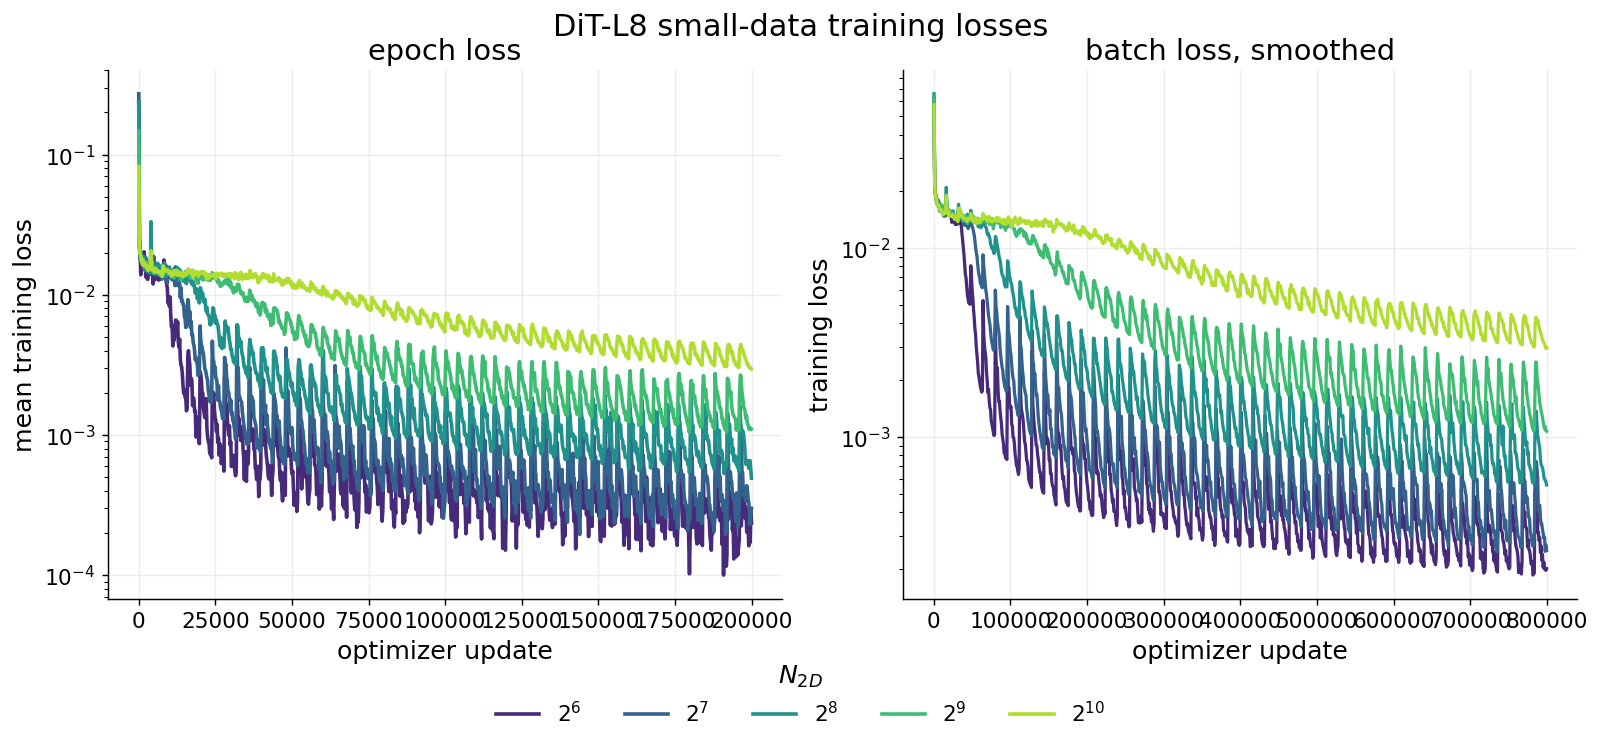

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_l8_small_data_loss_curves.png


### DiT-L12 / base loss curves for $2^6$--$2^{10}$

,arch_label,dataset_tag,dataset_size,n_epoch_loss,final_epoch_loss,best_epoch_loss,n_batch_loss,final_batch_loss,metrics_path
0,DiT-base,d2p06,64,25000,0.000184,0.000049,800000,0.000046,/scratch/huterer_root/huterer0/jiamingp/saved_...
1,DiT-base,d2p07,128,12500,0.000217,0.000142,800000,0.000191,/scratch/huterer_root/huterer0/jiamingp/saved_...
2,DiT-base,d2p08,256,6250,0.000442,0.000344,800000,0.000168,/scratch/huterer_root/huterer0/jiamingp/saved_...
3,DiT-base,d2p09,512,3125,0.000810,0.000756,800000,0.000816,/scratch/huterer_root/huterer0/jiamingp/saved_...
4,DiT-base,d2p10,1024,1563,0.001528,0.001528,800256,0.001304,/scratch/huterer_root/huterer0/jiamingp/saved_...


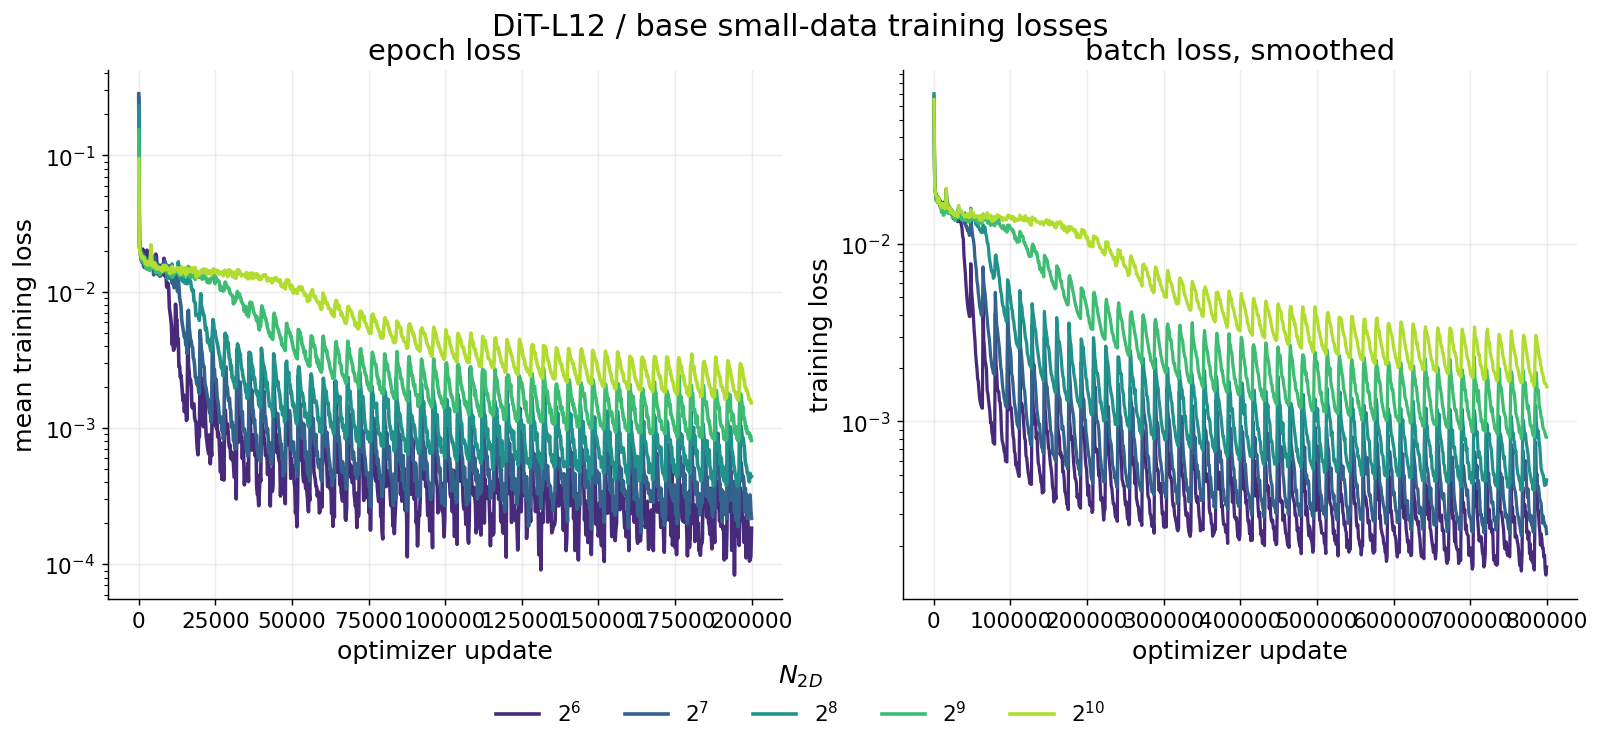

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_base_small_data_loss_curves.png


### DiT-L16 loss curves for $2^6$--$2^{10}$

,arch_label,dataset_tag,dataset_size,n_epoch_loss,final_epoch_loss,best_epoch_loss,n_batch_loss,final_batch_loss,metrics_path
10,DiT-L16,d2p06,64,25000,0.000151,0.000050,800000,0.000029,/scratch/huterer_root/huterer0/jiamingp/saved_...
11,DiT-L16,d2p07,128,12500,0.000264,0.000108,800000,0.000130,/scratch/huterer_root/huterer0/jiamingp/saved_...
12,DiT-L16,d2p08,256,6250,0.000345,0.000272,800000,0.000084,/scratch/huterer_root/huterer0/jiamingp/saved_...
13,DiT-L16,d2p09,512,3125,0.000592,0.000533,800000,0.000201,/scratch/huterer_root/huterer0/jiamingp/saved_...
14,DiT-L16,d2p10,1024,1563,0.001321,0.001287,800256,0.001413,/scratch/huterer_root/huterer0/jiamingp/saved_...


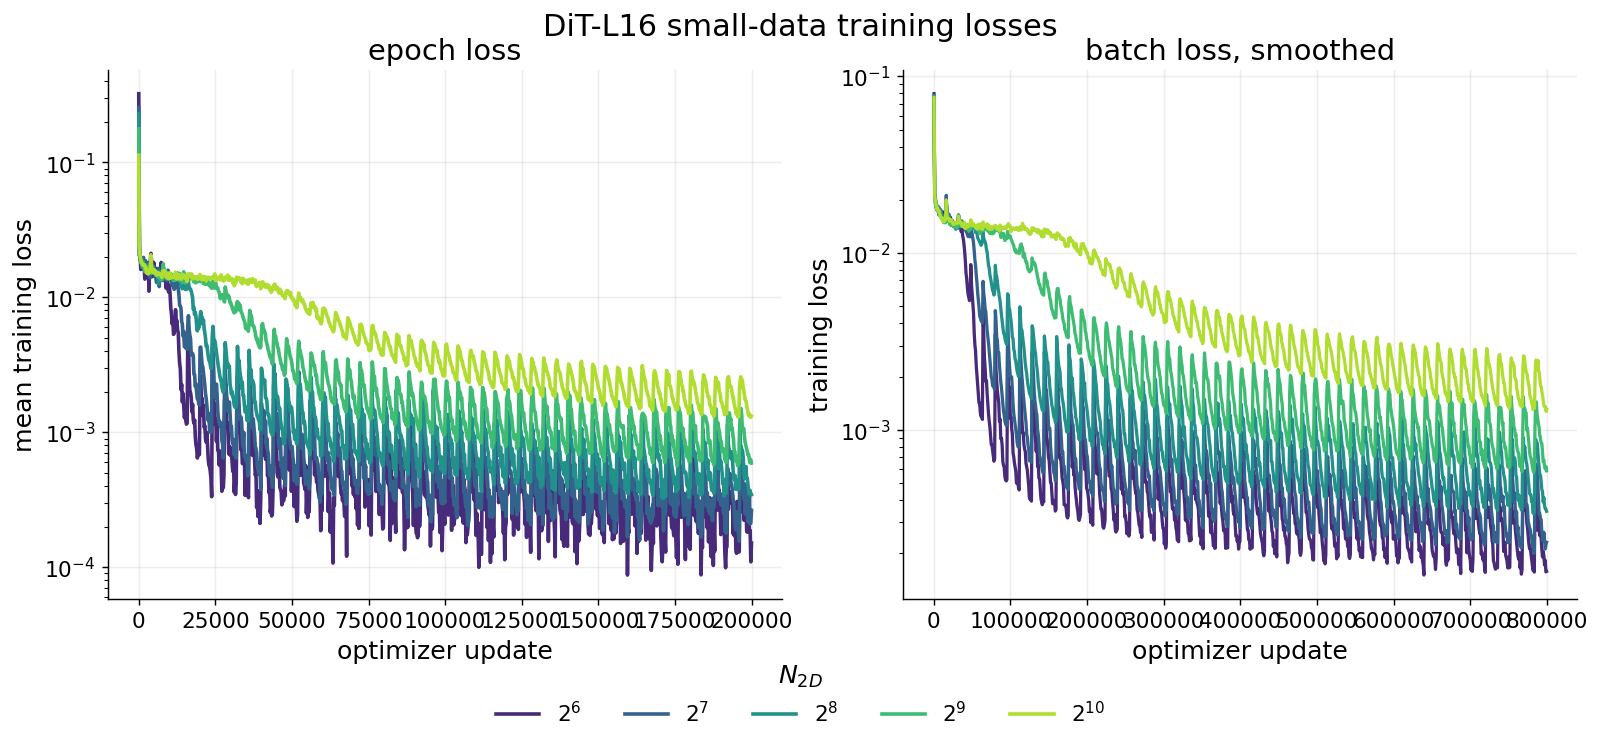

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_l16_small_data_loss_curves.png


In [11]:
def plot_small_data_loss_curves(
    arch: str,
    tags: list[str] = SANITY_TAGS,
) -> Path | None:
    if manifest_df.empty or 'loss_by_run' not in globals():
        display(Markdown('No manifest/loss cache available for focused loss curves.'))
        return None

    plot_df = manifest_df[(manifest_df['arch'].astype(str) == arch) & manifest_df['dataset_tag'].astype(str).isin(tags)].copy()
    if plot_df.empty:
        display(Markdown(f'No manifest rows found for `{arch_label(arch)}` focused loss curves.'))
        return None
    plot_df = plot_df.sort_values('dataset_size')

    if 'loss_df' in globals() and isinstance(loss_df, pd.DataFrame) and not loss_df.empty:
        focus_loss = loss_df[(loss_df['arch'].astype(str) == arch) & loss_df['dataset_tag'].astype(str).isin(tags)].copy()
        focus_cols = [c for c in [
            'arch_label', 'dataset_tag', 'dataset_size', 'n_epoch_loss',
            'final_epoch_loss', 'best_epoch_loss', 'n_batch_loss', 'final_batch_loss', 'metrics_path'
        ] if c in focus_loss.columns]
        if focus_cols:
            display(focus_loss.sort_values('dataset_size')[focus_cols])

    if not any(len(np.asarray(loss_by_run.get(str(row['run_name']), {}).get('epoch_loss', []))) or
               len(np.asarray(loss_by_run.get(str(row['run_name']), {}).get('batch_loss', [])))
               for _, row in plot_df.iterrows()):
        display(Markdown(f'No loss arrays found for `{arch_label(arch)}` focused loss curves.'))
        return None

    colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(plot_df)))
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.9), constrained_layout=True)
    for color, (_, row) in zip(colors, plot_df.iterrows()):
        run_name = str(row.get('run_name'))
        info = loss_by_run.get(run_name, {})
        label = dataset_size_label(int(row['dataset_size']))
        steps_per_epoch = max(1, int(row.get('steps_per_epoch', 1) or 1))

        epoch_loss = np.asarray(info.get('epoch_loss', []), dtype=float)
        if len(epoch_loss):
            x = np.arange(len(epoch_loss), dtype=float) * steps_per_epoch
            x, y = downsample_xy(x, epoch_loss, max_points=900)
            axes[0].plot(x, y, lw=2.0, color=color, label=label)

        batch_loss = np.asarray(info.get('batch_loss', []), dtype=float)
        if len(batch_loss):
            x = np.arange(len(batch_loss), dtype=float)
            y = batch_loss.copy()
            window = max(1, len(y) // 900)
            if window > 1:
                kernel = np.ones(window, dtype=float) / window
                y = np.convolve(y, kernel, mode='valid')
                x = x[:len(y)] + 0.5 * (window - 1)
            x, y = downsample_xy(x, y, max_points=900)
            axes[1].plot(x, y, lw=1.8, color=color, label=label)

    axes[0].set_title('epoch loss')
    axes[0].set_xlabel('optimizer update')
    axes[0].set_ylabel('mean training loss')
    axes[1].set_title('batch loss, smoothed')
    axes[1].set_xlabel('optimizer update')
    axes[1].set_ylabel('training loss')
    for ax in axes:
        ax.grid(alpha=0.22)
        if ax.has_data():
            ax.set_yscale('log')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title=r'$N_{2D}$', loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=len(labels), frameon=False)
    fig.suptitle(f'{arch_label(arch)} small-data training losses', y=1.03)

    out = QUICKCHECK_DIR / f'nf_generalize_fig2_{arch}_small_data_loss_curves.png'
    QUICKCHECK_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print('wrote', out)
    return out


small_data_loss_paths = {}
for arch in SANITY_ARCHES:
    display(Markdown(f'### {arch_label(arch)} loss curves for $2^6$--$2^{{10}}$'))
    small_data_loss_paths[arch] = plot_small_data_loss_curves(arch=arch)

## DiT Generalization Curves

The main DiT readout is the generalization score versus training-set size. A score near zero means generated fields are often too close to training slices under the chosen embedding. A score near one means generated fields are not unusually close to the training set relative to the real-data baseline.


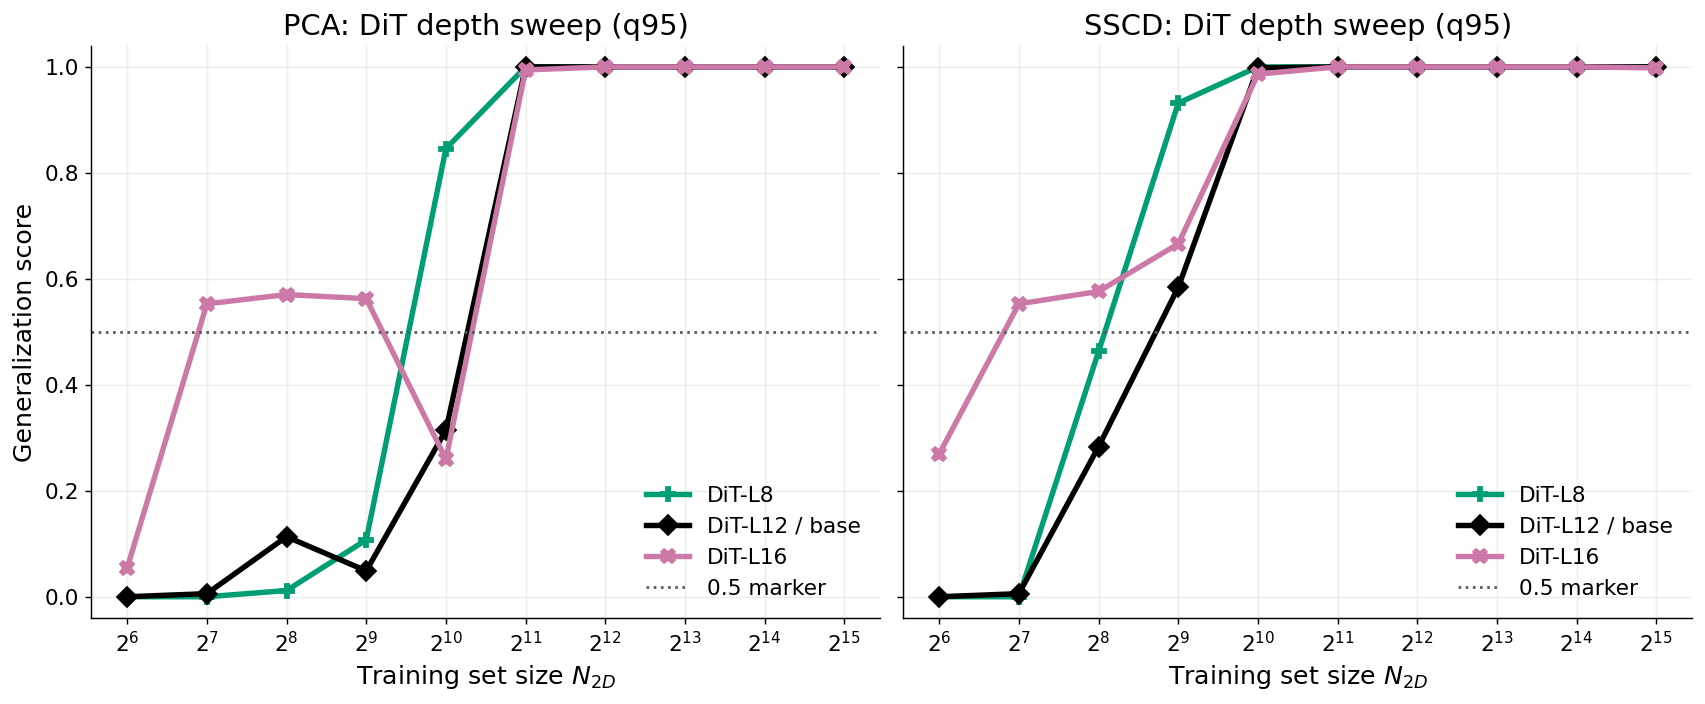

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_depth_gl_curves_q95.png


In [12]:
def format_power_ticks(ax, values):
    vals = sorted({int(v) for v in values if pd.notna(v) and v > 0})
    if not vals:
        return
    ax.set_xscale('log', base=2)
    ax.set_xticks(vals)
    ax.set_xticklabels([rf'$2^{{{int(round(math.log2(v)))}}}$' for v in vals])


def plot_dit_generalization_curves(metrics_by_feature: dict[str, pd.DataFrame], quantile: str = 'q95') -> Path | None:
    gl_col = f'gen_gl_{quantile}'
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.3), sharey=True, constrained_layout=True)
    plotted = False

    for ax, (feature_name, df) in zip(axes, metrics_by_feature.items()):
        all_x = []
        if df.empty or gl_col not in df.columns or 'dataset_size' not in df.columns:
            ax.set_visible(False)
            continue
        df = ensure_arch_columns(df)
        for arch in DIT_ARCH_ORDER:
            sub = df[df['arch'].astype(str) == arch].dropna(subset=['dataset_size', gl_col]).sort_values('dataset_size')
            if sub.empty:
                continue
            all_x.extend(sub['dataset_size'].astype(float).tolist())
            ax.plot(
                sub['dataset_size'], sub[gl_col],
                marker=DIT_ARCH_MARKERS.get(arch, 'o'), ms=8, lw=3,
                color=DIT_ARCH_COLORS.get(arch, '0.2'), label=arch_label(arch),
            )
            plotted = True
        format_power_ticks(ax, all_x)
        ax.axhline(0.5, color='0.35', lw=1.5, ls=':', label='0.5 marker')
        ax.set_ylim(-0.04, 1.04)
        ax.set_xlabel(r'Training set size $N_{2D}$')
        ax.set_title(f'{feature_name}: DiT depth sweep ({quantile})')
        ax.grid(True, alpha=0.22)
        ax.legend(frameon=False, loc='lower right')
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    axes[0].set_ylabel('Generalization score')

    if not plotted:
        display(Markdown(f'No `{gl_col}` columns found to plot.'))
        plt.close(fig)
        return None

    QUICKCHECK_DIR.mkdir(parents=True, exist_ok=True)
    out = QUICKCHECK_DIR / f'nf_generalize_fig2_dit_depth_gl_curves_{quantile}.png'
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print('wrote', out)
    return out

combined_curve = plot_dit_generalization_curves({'PCA': pca_metrics, 'SSCD': sscd_metrics}, quantile='q95')

## Transition Summary

`N50` is the interpolated training-set size where the generalization score crosses 0.5. This is a compact way to compare transitions, but it should be read with the full curve because a single midpoint can hide changes in slope or tail behavior.


In [13]:
def interpolate_crossing(df: pd.DataFrame, ycol: str, threshold: float = 0.5) -> dict[str, Any]:
    if df.empty or ycol not in df.columns or 'dataset_size' not in df.columns:
        return {'status': 'missing', 'n_cross': np.nan, 'log2_n_cross': np.nan}
    sub = df[['dataset_size', ycol]].dropna().sort_values('dataset_size')
    sub = sub[sub['dataset_size'] > 0]
    if sub.empty:
        return {'status': 'missing', 'n_cross': np.nan, 'log2_n_cross': np.nan}

    x = np.log2(sub['dataset_size'].astype(float).to_numpy())
    y = sub[ycol].astype(float).to_numpy()
    if y[0] >= threshold:
        return {'status': 'left_censored', 'n_cross': 2 ** x[0], 'log2_n_cross': x[0]}
    if y[-1] < threshold:
        return {'status': 'right_censored', 'n_cross': 2 ** x[-1], 'log2_n_cross': x[-1]}

    for i in range(len(y) - 1):
        y0, y1 = y[i], y[i + 1]
        if (y0 <= threshold <= y1) or (y1 <= threshold <= y0):
            if y1 == y0:
                xc = x[i]
            else:
                frac = (threshold - y0) / (y1 - y0)
                xc = x[i] + frac * (x[i + 1] - x[i])
            return {'status': 'interpolated', 'n_cross': 2 ** xc, 'log2_n_cross': xc}
    return {'status': 'not_found', 'n_cross': np.nan, 'log2_n_cross': np.nan}


rows = []
for feature_name, df in [('PCA', pca_metrics), ('SSCD', sscd_metrics)]:
    df = ensure_arch_columns(df)
    for arch in DIT_ARCH_ORDER:
        sub = df[df['arch'].astype(str) == arch]
        for q in ['q90', 'q95', 'q99']:
            col = f'gen_gl_{q}'
            result = interpolate_crossing(sub, col, threshold=0.5)
            rows.append({
                'feature': feature_name,
                'arch': arch,
                'arch_label': arch_label(arch),
                'score_col': col,
                'threshold': 0.5,
                **result,
            })

transition_df = pd.DataFrame(rows)
display(transition_df.sort_values(['feature', 'arch', 'score_col']))

if len(transition_df):
    out = TABLE_DIR / 'nf_generalize_fig2_dit_transition_summary.csv'
    TABLE_DIR.mkdir(parents=True, exist_ok=True)
    transition_df.to_csv(out, index=False)
    print('wrote', out)

,feature,arch,arch_label,score_col,threshold,status,n_cross,log2_n_cross
3,PCA,dit_base,DiT-L12 / base,gen_gl_q90,0.5,interpolated,1312.767753,10.358396
4,PCA,dit_base,DiT-L12 / base,gen_gl_q95,0.5,interpolated,1235.308164,10.270655
5,PCA,dit_base,DiT-L12 / base,gen_gl_q99,0.5,interpolated,839.493763,9.713376
6,PCA,dit_l16,DiT-L16,gen_gl_q90,0.5,interpolated,119.077159,6.895753
7,PCA,dit_l16,DiT-L16,gen_gl_q95,0.5,interpolated,118.942265,6.894118
8,PCA,dit_l16,DiT-L16,gen_gl_q99,0.5,interpolated,118.907902,6.893701
0,PCA,dit_l8,DiT-L8,gen_gl_q90,0.5,interpolated,825.612148,9.689320
1,PCA,dit_l8,DiT-L8,gen_gl_q95,0.5,interpolated,740.187023,9.531746
2,PCA,dit_l8,DiT-L8,gen_gl_q99,0.5,interpolated,684.156145,9.418182
12,SSCD,dit_base,DiT-L12 / base,gen_gl_q90,0.5,interpolated,555.501524,9.117647


wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/tables/nf_generalize_fig2_dit_transition_summary.csv


## Compare DiT Depths With Existing UNet Sweep (Optional)

This is the main architecture comparison. It overlays each DiT depth on the existing UNet Fig.2 curves. If DiT-L12/base sits near UNet-128 in parameter count but transitions later, that is evidence that the architecture/inductive bias matters, not just raw parameter count.

loaded results/nf_generalize_fig2/tables/nf_generalize_fig2_pca_full_nn_metrics.csv: 30 rows, 89 columns
loaded results/nf_generalize_fig2/tables/nf_generalize_fig2_sscd_full_nn_metrics.csv: 30 rows, 89 columns


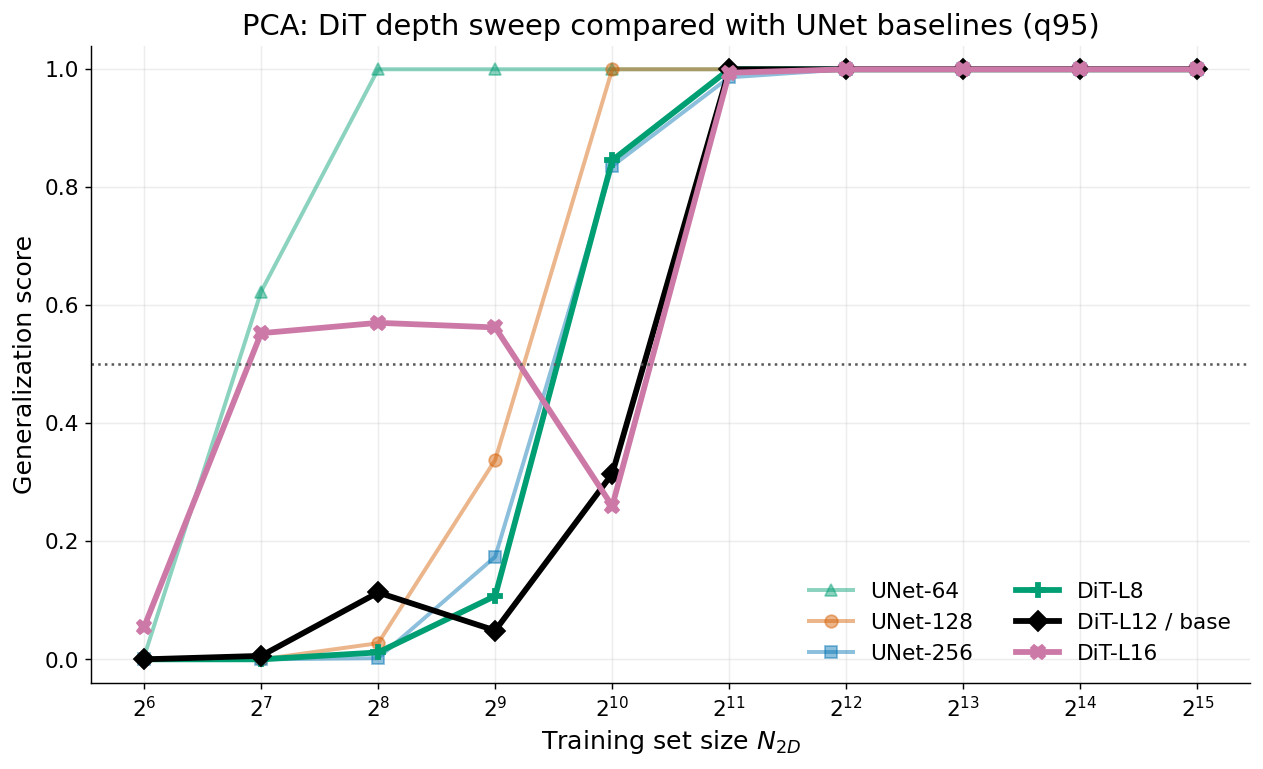

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_depth_vs_unet_pca_q95.png


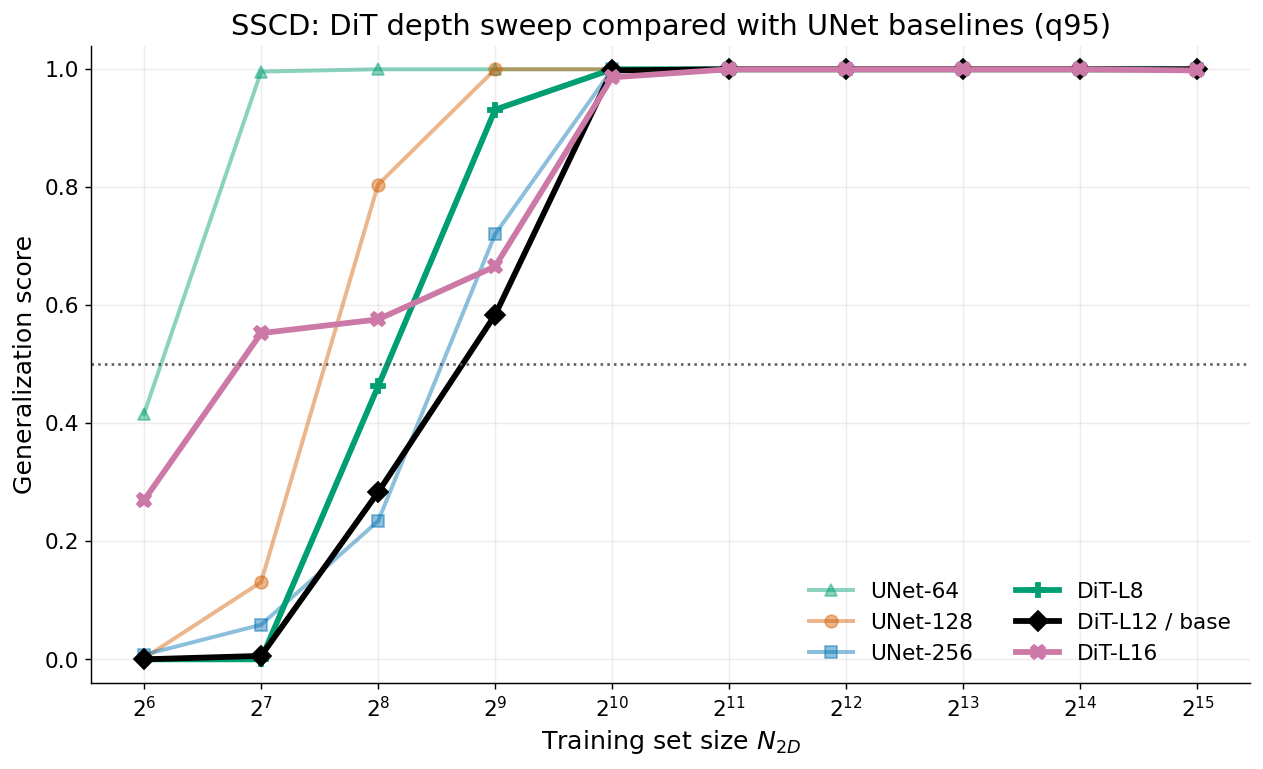

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_depth_vs_unet_sscd_q95.png


In [14]:
UNET_RESULTS_DIR = PROJECT_DIR / 'results' / 'nf_generalize_fig2'
UNET_TABLE_DIR = UNET_RESULTS_DIR / 'tables'

unet_pca = add_generalization_columns(read_csv_if_exists(UNET_TABLE_DIR / 'nf_generalize_fig2_pca_full_nn_metrics.csv'))
unet_sscd = add_generalization_columns(read_csv_if_exists(UNET_TABLE_DIR / 'nf_generalize_fig2_sscd_full_nn_metrics.csv'))


def plot_dit_vs_unet(feature_name: str, dit_df: pd.DataFrame, unet_df: pd.DataFrame, quantile: str = 'q95') -> Path | None:
    gl_col = f'gen_gl_{quantile}'
    if dit_df.empty or gl_col not in dit_df.columns:
        display(Markdown(f'No DiT `{feature_name}` `{gl_col}` data.'))
        return None

    fig, ax = plt.subplots(figsize=(9.6, 5.8), constrained_layout=True)
    all_x = []

    if not unet_df.empty and gl_col in unet_df.columns:
        tmp = ensure_arch_columns(unet_df)
        for arch in UNET_ARCH_ORDER:
            sub = tmp[tmp['arch'].astype(str) == arch].dropna(subset=['dataset_size', gl_col]).sort_values('dataset_size')
            if sub.empty:
                continue
            all_x.extend(sub['dataset_size'].astype(float).tolist())
            ax.plot(
                sub['dataset_size'], sub[gl_col],
                color=UNET_ARCH_COLORS[arch], marker=UNET_ARCH_MARKERS[arch], lw=2.2, ms=7,
                alpha=0.45, label=arch_label(arch),
            )

    dit = ensure_arch_columns(dit_df)
    for arch in DIT_ARCH_ORDER:
        sub = dit[dit['arch'].astype(str) == arch].dropna(subset=['dataset_size', gl_col]).sort_values('dataset_size')
        if sub.empty:
            continue
        all_x.extend(sub['dataset_size'].astype(float).tolist())
        ax.plot(
            sub['dataset_size'], sub[gl_col],
            color=DIT_ARCH_COLORS.get(arch, 'black'), marker=DIT_ARCH_MARKERS.get(arch, 'D'), lw=3.2, ms=8.2,
            label=arch_label(arch),
        )

    ax.axhline(0.5, color='0.35', lw=1.4, ls=':')
    format_power_ticks(ax, all_x)
    ax.set_ylim(-0.04, 1.04)
    ax.set_xlabel(r'Training set size $N_{2D}$')
    ax.set_ylabel('Generalization score')
    ax.set_title(f'{feature_name}: DiT depth sweep compared with UNet baselines ({quantile})')
    ax.grid(True, alpha=0.22)
    ax.legend(frameon=False, ncol=2, loc='lower right')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    out = QUICKCHECK_DIR / f'nf_generalize_fig2_dit_depth_vs_unet_{feature_name.lower()}_{quantile}.png'
    fig.savefig(out, bbox_inches='tight')
    plt.show()
    print('wrote', out)
    return out

_ = plot_dit_vs_unet('PCA', pca_metrics, unet_pca, quantile='q95')
_ = plot_dit_vs_unet('SSCD', sscd_metrics, unet_sscd, quantile='q95')

## Capacity Check: DiT Depth vs UNet Width

This table/plot is a diagnostic, not a final scaling law. It asks: at the q95 threshold, how many 2D images are needed before each model reaches generalization score 0.5? The x-axis is trainable parameter count, and the y-axis is the interpolated crossing size `N50`.

,feature,model,family,model_params_m,status,n_cross,log2_n_cross
0,PCA,DiT-L8,DiT,95.000000,interpolated,740.187023,9.531746
1,PCA,DiT-L12 / base,DiT,138.290000,interpolated,1235.308164,10.270655
2,PCA,DiT-L16,DiT,182.000000,interpolated,118.942265,6.894118
3,PCA,UNet-64,UNet,26.621057,interpolated,111.527976,6.801262
4,PCA,UNet-128,UNet,140.539521,interpolated,606.699267,9.244838
5,PCA,UNet-256,UNet,196.059905,interpolated,720.385518,9.492625
6,SSCD,DiT-L8,DiT,95.000000,interpolated,270.440361,8.079167
7,SSCD,DiT-L12 / base,DiT,138.290000,interpolated,421.906417,8.720779
8,SSCD,DiT-L16,DiT,182.000000,interpolated,112.500929,6.813793
9,SSCD,UNet-64,UNet,26.621057,interpolated,70.756027,6.144781


,feature,comparison,param_ratio,n50_ratio,dit_log2_n50,baseline_log2_n50
0,PCA,DiT-L8 / UNet-128,0.675966,1.220023,9.531746,9.244838
1,PCA,DiT-L8 / UNet-256,0.484546,1.027487,9.531746,9.492625
2,PCA,DiT-L12 / base / UNet-128,0.983994,2.036113,10.270655,9.244838
3,PCA,DiT-L12 / base / UNet-256,0.705346,1.714788,10.270655,9.492625
4,PCA,DiT-L16 / UNet-128,1.295009,0.196048,6.894118,9.244838
5,PCA,DiT-L16 / UNet-256,0.928288,0.165109,6.894118,9.492625
6,SSCD,DiT-L8 / UNet-128,0.675966,1.445272,8.079167,7.547826
7,SSCD,DiT-L8 / UNet-256,0.484546,0.723458,8.079167,8.546185
8,SSCD,DiT-L12 / base / UNet-128,0.983994,2.254728,8.720779,7.547826
9,SSCD,DiT-L12 / base / UNet-256,0.705346,1.128647,8.720779,8.546185


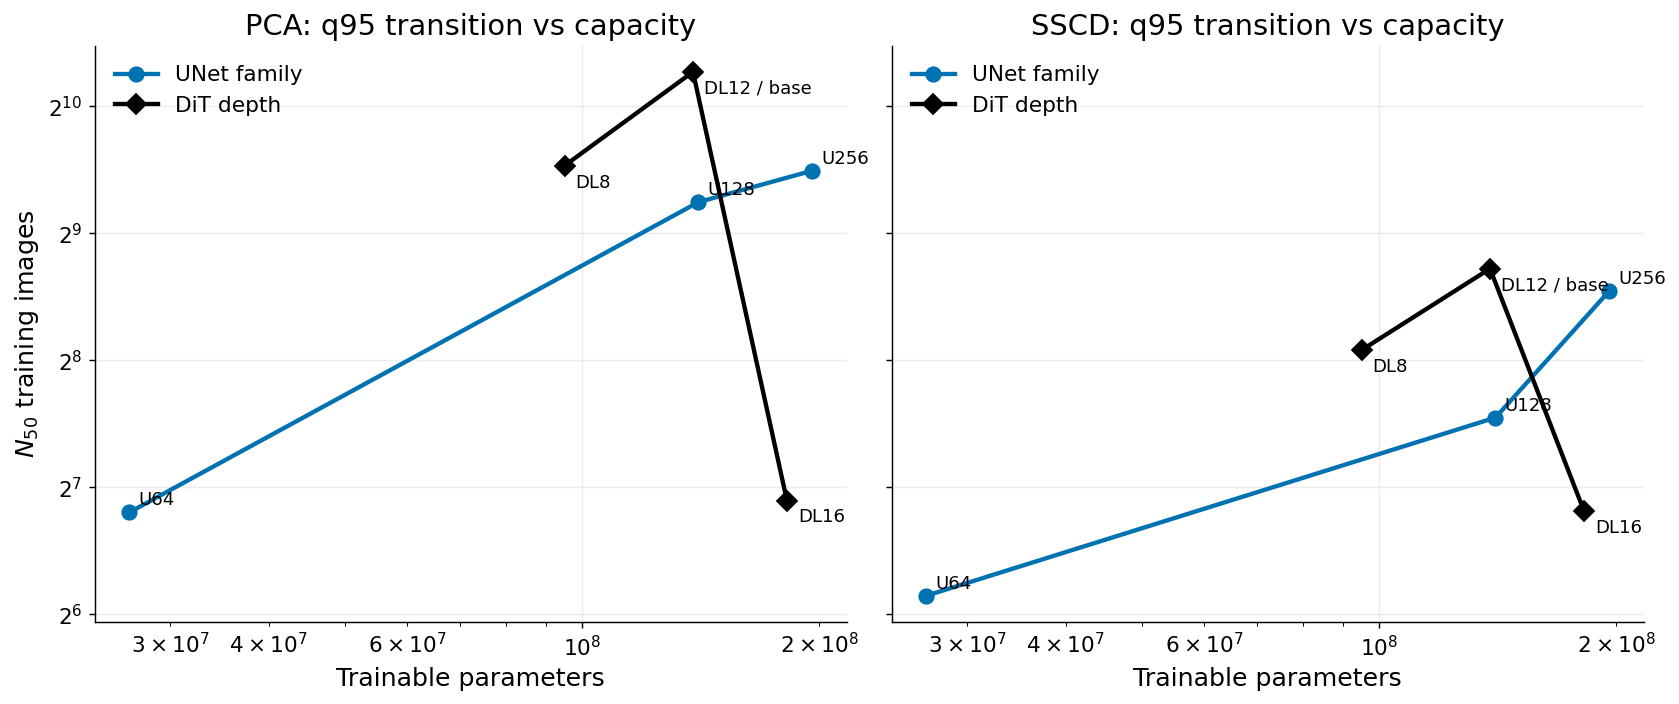

wrote /home/jiamingp/diffusion_models_repo/results/nf_generalize_fig2_dit/quickcheck/nf_generalize_fig2_dit_depth_capacity_n50_q95.png


### Capacity interpretation
- PCA: DiT-L8 / UNet-128 has 0.68x parameters and 1.22x the q95 N50.
- PCA: DiT-L8 / UNet-256 has 0.48x parameters and 1.03x the q95 N50.
- PCA: DiT-L12 / base / UNet-128 has 0.98x parameters and 2.04x the q95 N50.
- PCA: DiT-L12 / base / UNet-256 has 0.71x parameters and 1.71x the q95 N50.
- PCA: DiT-L16 / UNet-128 has 1.30x parameters and 0.20x the q95 N50.
- PCA: DiT-L16 / UNet-256 has 0.93x parameters and 0.17x the q95 N50.
- SSCD: DiT-L8 / UNet-128 has 0.68x parameters and 1.45x the q95 N50.
- SSCD: DiT-L8 / UNet-256 has 0.48x parameters and 0.72x the q95 N50.
- SSCD: DiT-L12 / base / UNet-128 has 0.98x parameters and 2.25x the q95 N50.
- SSCD: DiT-L12 / base / UNet-256 has 0.71x parameters and 1.13x the q95 N50.
- SSCD: DiT-L16 / UNet-128 has 1.30x parameters and 0.60x the q95 N50.
- SSCD: DiT-L16 / UNet-256 has 0.93x parameters and 0.30x the q95 N50.
- This is a capacity/architecture diagnostic, not a universal scaling law. The useful question is whether DiT depth moves the transition coherently, and whether DiT differs from a parameter-matched UNet.

In [15]:
# Parameter counts.
# UNet values are exact from the existing sweep. DiT values are approximate for width 768,
# patch 8, and depths 8/12/16; replace with print_model_param_count.py values if needed.
MODEL_CAPACITY = pd.DataFrame([
    {'model': 'UNet-64',        'family': 'UNet', 'arch_key': 'u64',      'model_params': 26_621_057,  'source': 'exact'},
    {'model': 'UNet-128',       'family': 'UNet', 'arch_key': 'u128',     'model_params': 140_539_521, 'source': 'exact'},
    {'model': 'UNet-256',       'family': 'UNet', 'arch_key': 'u256',     'model_params': 196_059_905, 'source': 'exact'},
    {'model': 'DiT-L8',         'family': 'DiT',  'arch_key': 'dit_l8',   'model_params': 95_000_000,  'source': 'approx'},
    {'model': 'DiT-L12 / base', 'family': 'DiT',  'arch_key': 'dit_base', 'model_params': 138_290_000, 'source': 'approx'},
    {'model': 'DiT-L16',        'family': 'DiT',  'arch_key': 'dit_l16',  'model_params': 182_000_000, 'source': 'approx'},
])
MODEL_CAPACITY['model_params_m'] = MODEL_CAPACITY['model_params'] / 1e6


def n50_for_model(feature_name: str, model: str, family: str, model_params: int, df: pd.DataFrame, q: str = 'q95') -> dict[str, Any]:
    col = f'gen_gl_{q}'
    cross = interpolate_crossing(df, col, threshold=0.5)
    return {
        'feature': feature_name,
        'model': model,
        'family': family,
        'model_params': model_params,
        'model_params_m': model_params / 1e6,
        'score_col': col,
        **cross,
    }


def capacity_transition_table(q: str = 'q95') -> pd.DataFrame:
    rows = []
    feature_frames = {
        'PCA': (pca_metrics, unet_pca),
        'SSCD': (sscd_metrics, unet_sscd),
    }
    for feature_name, (dit_df, unet_df) in feature_frames.items():
        dit_tmp = ensure_arch_columns(dit_df)
        for arch in DIT_ARCH_ORDER:
            cap = MODEL_CAPACITY[MODEL_CAPACITY['arch_key'] == arch]
            if cap.empty:
                continue
            cap = cap.iloc[0]
            sub = dit_tmp[dit_tmp['arch'].astype(str) == arch]
            rows.append(n50_for_model(feature_name, cap['model'], cap['family'], int(cap['model_params']), sub, q=q))

        if unet_df.empty:
            continue
        unet_tmp = ensure_arch_columns(unet_df)
        for arch in UNET_ARCH_ORDER:
            cap = MODEL_CAPACITY[MODEL_CAPACITY['arch_key'] == arch].iloc[0]
            sub = unet_tmp[unet_tmp['arch'].astype(str) == arch]
            rows.append(n50_for_model(feature_name, cap['model'], cap['family'], int(cap['model_params']), sub, q=q))
    out = pd.DataFrame(rows)
    return out.sort_values(['feature', 'family', 'model_params']).reset_index(drop=True)


capacity_n50 = capacity_transition_table(q='q95')
display(capacity_n50[['feature', 'model', 'family', 'model_params_m', 'status', 'n_cross', 'log2_n_cross']])

# Pairwise comparison against nearby UNet capacities.
ratio_rows = []
for feature_name in ['PCA', 'SSCD']:
    sub = capacity_n50[capacity_n50['feature'] == feature_name].set_index('model')
    for dit_model in ['DiT-L8', 'DiT-L12 / base', 'DiT-L16']:
        if dit_model not in sub.index:
            continue
        for baseline in ['UNet-128', 'UNet-256']:
            if baseline not in sub.index:
                continue
            ratio_rows.append({
                'feature': feature_name,
                'comparison': f'{dit_model} / {baseline}',
                'param_ratio': sub.loc[dit_model, 'model_params'] / sub.loc[baseline, 'model_params'],
                'n50_ratio': sub.loc[dit_model, 'n_cross'] / sub.loc[baseline, 'n_cross'],
                'dit_log2_n50': sub.loc[dit_model, 'log2_n_cross'],
                'baseline_log2_n50': sub.loc[baseline, 'log2_n_cross'],
            })
capacity_ratios = pd.DataFrame(ratio_rows)
display(capacity_ratios)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.3), sharey=True, constrained_layout=True)
for ax, feature_name in zip(axes, ['PCA', 'SSCD']):
    sub = capacity_n50[(capacity_n50['feature'] == feature_name) & capacity_n50['n_cross'].notna()].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    unet = sub[sub['family'] == 'UNet'].sort_values('model_params')
    dit = sub[sub['family'] == 'DiT'].sort_values('model_params')
    if len(unet):
        ax.plot(unet['model_params'], unet['n_cross'], color='#0072B2', marker='o', lw=2.4, ms=8, label='UNet family')
        for _, row in unet.iterrows():
            ax.annotate(row['model'].replace('UNet-', 'U'), (row['model_params'], row['n_cross']), xytext=(5, 4), textcoords='offset points', fontsize=10)
    if len(dit):
        ax.plot(dit['model_params'], dit['n_cross'], color='black', marker='D', lw=2.4, ms=8, label='DiT depth')
        for _, row in dit.iterrows():
            ax.annotate(row['model'].replace('DiT-', 'D'), (row['model_params'], row['n_cross']), xytext=(6, -12), textcoords='offset points', fontsize=10, color='black')
    ax.set_xscale('log')
    ax.set_yscale('log', base=2)
    ax.set_xlabel('Trainable parameters')
    ax.set_title(f'{feature_name}: q95 transition vs capacity')
    ax.grid(True, alpha=0.22)
    ax.legend(frameon=False, loc='upper left')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel(r'$N_{50}$ training images')

out = QUICKCHECK_DIR / 'nf_generalize_fig2_dit_depth_capacity_n50_q95.png'
fig.savefig(out, bbox_inches='tight')
plt.show()
print('wrote', out)

if not capacity_ratios.empty:
    lines = ['### Capacity interpretation']
    for _, row in capacity_ratios.iterrows():
        if not np.isfinite(row['n50_ratio']):
            continue
        lines.append(
            f"- {row['feature']}: {row['comparison']} has {row['param_ratio']:.2f}x parameters "
            f"and {row['n50_ratio']:.2f}x the q95 N50."
        )
    lines.append('- This is a capacity/architecture diagnostic, not a universal scaling law. The useful question is whether DiT depth moves the transition coherently, and whether DiT differs from a parameter-matched UNet.')
    display(Markdown('\n'.join(lines)))

## Existing Quickcheck Figures and Saved Diagnostics


In [ ]:
def show_existing_figure(path: Path, title: str, width: int = 950) -> None:
    display(Markdown(f'### {title}'))
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f'Missing: `{rel(path)}`'))

show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_training_curves.png', 'DiT training curves')
for arch in DIT_ARCH_ORDER:
    show_existing_figure(QUICKCHECK_DIR / f'nf_generalize_fig2_{arch}_generated_image_grid.png', f'{arch_label(arch)} generated image grid')
    show_existing_figure(QUICKCHECK_DIR / f'nf_generalize_fig2_{arch}_detail_onepoint_pk.png', f'{arch_label(arch)} one-point and P(k) fidelity')
show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_depth_gl_curves_q95.png', 'DiT depth GL curves')
show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_depth_vs_unet_pca_q95.png', 'PCA DiT vs UNet')
show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_depth_vs_unet_sscd_q95.png', 'SSCD DiT vs UNet')
show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_depth_capacity_n50_q95.png', 'DiT depth capacity diagnostic')
show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_pca_full_nn_paper_style_gl_curves.png', 'PCA paper-style GL curves')
show_existing_figure(QUICKCHECK_DIR / 'nf_generalize_fig2_dit_sscd_full_nn_paper_style_gl_curves.png', 'SSCD paper-style GL curves')

## Sample File Sanity Check

This inspects array keys and shapes without doing the expensive nearest-neighbor analysis again.


In [17]:
def inspect_npz(path: Path) -> dict[str, Any]:
    if not path.exists():
        return {'exists': False}
    with np.load(path) as data:
        keys = list(data.files)
        first = keys[0] if keys else None
        arr = data[first] if first else None
        return {
            'exists': True,
            'keys': ', '.join(keys[:8]),
            'first_key': first,
            'shape': tuple(arr.shape) if arr is not None else None,
            'dtype': str(arr.dtype) if arr is not None else None,
            'size_mb': path.stat().st_size / 1024**2,
        }

if manifest_df.empty:
    display(Markdown('No manifest available, so sample files were not inspected.'))
else:
    rows = []
    for _, row in manifest_df.sort_values(['arch', 'dataset_size']).iterrows():
        path = row['sample_path_resolved']
        info = inspect_npz(path)
        rows.append({
            'arch_label': row.get('arch_label'),
            'dataset_tag': row.get('dataset_tag'),
            'dataset_size': row.get('dataset_size'),
            'path': rel(path),
            **info,
        })
    sample_inspect_df = pd.DataFrame(rows)
    display(sample_inspect_df)

,arch_label,dataset_tag,dataset_size,path,exists,keys,first_key,shape,dtype,size_mb
0,DiT-base,d2p06,64,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
1,DiT-base,d2p07,128,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
2,DiT-base,d2p08,256,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
3,DiT-base,d2p09,512,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
4,DiT-base,d2p10,1024,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
5,DiT-base,d2p11,2048,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
6,DiT-base,d2p12,4096,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
7,DiT-base,d2p13,8192,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
8,DiT-base,d2p14,16384,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256
9,DiT-base,d2p15,32768,results/nf_generalize_fig2_dit/samples/nf_fig2...,True,samples,samples,"(512, 1, 128, 128)",float32,32.000256


## Takeaways


In [18]:
def best_transition_lines(feature: str) -> list[str]:
    if transition_df.empty:
        return [f'- {feature}: transition table missing.']
    lines = []
    for arch in DIT_ARCH_ORDER:
        sub = transition_df[
            (transition_df['feature'] == feature)
            & (transition_df['arch'] == arch)
            & (transition_df['score_col'] == 'gen_gl_q95')
        ]
        label = arch_label(arch)
        if sub.empty:
            lines.append(f'- {feature} {label}: q95 generalization column missing.')
            continue
        row = sub.iloc[0]
        if pd.isna(row['n_cross']):
            lines.append(f'- {feature} {label}: N50 not available ({row["status"]}).')
        else:
            lines.append(f'- {feature} {label}: q95 N50 = 2^{row["log2_n_cross"]:.2f} = {row["n_cross"]:.0f} 2D images ({row["status"]}).')
    return lines

sample_ok = None if manifest_df.empty else int(manifest_df['sample_exists'].sum())
sample_total = None if manifest_df.empty else len(manifest_df)

lines = ['### Notebook summary']
if sample_ok is not None:
    lines.append(f'- Sample audit: {sample_ok}/{sample_total} DiT sample files found.')
lines.extend(best_transition_lines('PCA'))
lines.extend(best_transition_lines('SSCD'))
lines.extend([
    '- Read PCA and SSCD together. PCA is sensitive to low-dimensional variance; SSCD is a learned image-similarity embedding. Agreement is stronger evidence than either diagnostic alone.',
    '- Main architecture question: does the transition move systematically with DiT depth, and does a DiT of similar parameter count behave differently from a UNet?',
])

display(Markdown('\n'.join(lines)))

### Notebook summary
- Sample audit: 30/30 DiT sample files found.
- PCA DiT-L8: q95 N50 = 2^9.53 = 740 2D images (interpolated).
- PCA DiT-L12 / base: q95 N50 = 2^10.27 = 1235 2D images (interpolated).
- PCA DiT-L16: q95 N50 = 2^6.89 = 119 2D images (interpolated).
- SSCD DiT-L8: q95 N50 = 2^8.08 = 270 2D images (interpolated).
- SSCD DiT-L12 / base: q95 N50 = 2^8.72 = 422 2D images (interpolated).
- SSCD DiT-L16: q95 N50 = 2^6.81 = 113 2D images (interpolated).
- Read PCA and SSCD together. PCA is sensitive to low-dimensional variance; SSCD is a learned image-similarity embedding. Agreement is stronger evidence than either diagnostic alone.
- Main architecture question: does the transition move systematically with DiT depth, and does a DiT of similar parameter count behave differently from a UNet?

## Great Lakes Rerun Command

From the repo root on Great Lakes:

```bash
cd /home/jiamingp/diffusion_models_repo
jupyter nbconvert --execute --to notebook --inplace notebooks/nf_generalize_fig2_dit_results.ipynb
```

If you are using the Jupyter web session, just open this notebook and run all cells. The heavy PCA/SSCD nearest-neighbor work should not rerun here; this notebook reads the completed CSV and PNG outputs.
